<table style="width: 100%; border: none;">
    <tr style="border: none;">
        <td style="width: 30%; border: none; text-align: left;">
            <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/a/a0/Logo_de_la_UPTC.svg/960px-Logo_de_la_UPTC.svg.png" alt="Logo UPTC" width="250"/>
        </td>
        <td style="width: 70%; border: none; text-align: center;">
            <h3 style="margin: 0; padding: 2px;">Especialización en Analítica Estratégica de Datos</h3>
            <h4 style="margin: 0; padding: 2px; font-weight: normal;">Notebook limpieza y procesamiento de datos (Media-mediana-MICE-Transformadas) | Modelos Analíticos</h4>
            <h3 style="margin: 0; padding: 5px;">Entregable # 2</h3>
        </td>
    </tr>
</table>

**Profesor:** Johan Diaz

**Estudiantes:**

- Gabriela VIllalobos
- Marco Diaz
- Ivan Mariño
- Diego Reyes

In [ ]:
!pip install ydata_profiling scikit_posthocs -q
import pandas as pd
import polars as pl
import polars.selectors as cs
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from ydata_profiling import ProfileReport
from pathlib import Path
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from scipy.stats import skew
from sklearn.preprocessing import PowerTransformer

 ## 1. Dataset previo

## 1.1. Resumen dataset original

| Nombre | Tipo | Tipo de variable | Descripción |
|---|---|---|---|
| viatico_id | int | Identificador | Un identificador único para cada registro de gastos de viaje o «viático». |
| commission_request_id | int | Identificador | Un identificador único para la solicitud de comisión o reembolso asociada al gasto de viaje. |
| total_travel_allowance | float | Cuantitativa continua | El importe total de la asignación de viaje o del reembolso del gasto. |
| purpose | string | Cualitativa nominal | La categoría o clasificación del motivo o razón del gasto de viaje. |
| full_date | date | Cualitativa ordinal | La fecha completa en el formato AAAA-MM-DD de inicio del viaje. |
| commission_days | int | Cuantitativa discreta | El número de días durante los cuales se incurrió en el gasto de viaje. |
| employee_position_norm | string | Cualitativa nominal | La versión normalizada y estandarizada del cargo o puesto del empleado. |
| position_level | int | Cualitativa ordinal | Un indicador del nivel jerárquico del empleado dentro de la organización. |
| city_origin | string | Cualitativa nominal | La ciudad de origen de la ruta de transporte. |
| city_destination_main | string | Cualitativa nominal | La ciudad de destino principal de la ruta de transporte. |
| distance_km | float | Cuantitativa continua | Distancia en kilómetros entre la ciudad de origen y destino. |
| destination_count | int | Cuantitativa discreta | El número de ciudades de destino a lo largo de la ruta. |
| is_contractor | boolean | Cualitativa nominal dicotómica | Un indicador que señala si el empleado es un contratista o un empleado a tiempo completo. |  

<br>

Este conjunto de datos recopila información sobre la gestión, asignación y reembolso de viáticos y gastos de viaje del personal de la Registraduría. Estructurado a nivel de registro único por viático o solicitud de comisión, el dataset integra variables financieras (como el monto total otorgado), temporales (fecha de inicio y días de duración) y cualitativas que explican el motivo del viaje. Incluye información sociolaboral clave sobre el perfil del empleado (cargo normalizado, nivel jerárquico y si es contratista o planta) junto con especificaciones logísticas y geográficas de las rutas atendidas, como las ciudades de origen y destino, la distancia recorrida en kilómetros y el total de destinos visitados. Ya que para actividades previas se solicitaba un histórico de al menos 3 años e inicialmente solo se poseían registro de un añó se decidió ampliar usando un LLM, por lo que, el origen del dataset es real y sintetico.

In [ ]:
registraduriaDatasetOriginal = pd.read_excel('/content/registraduria_database_clean.xlsx')

## Reporte de datos dataset original
profile = ProfileReport(
    registraduriaDatasetOriginal,
    title="Reporte Calidad Datos"
)

profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 14/14 [00:00<00:00, 17.34it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Los principales hallazgos del informe de perfil inicial nos permiten ver cuántos datos hay en el conjunto de datos: 15.753. También vemos que hay 5 variables categóricas y 6 numéricas en un total de 13 columnas.

**Correlación:** Al principio, vemos una correlación fuerte (0.552) entre la cantidad de días que dura la comisión y el valor total del viaje. También encontramos una relación fuerte entre las columnas relacionadas con el cargo, su nivel y el tipo de contrato.

**Valores nulos:** Encontramos 1.282 valores nulos en la columna “Nivel de cargo". Estos valores nulos corresponden a contratistas y otros, ya que sus perfiles no están estrictamente asociados a un nivel jerárquico.

**Calidad de datos:** En la columna de valores totales de los viajes, encontramos 416 valores en 0, aunque el valor de días de comisión es positivo (mayor a 0). Esto indica un problema de calidad de datos y una oportunidad para mejorar la recolección de información. Sin embargo, no es un dato muy representativo en comparación con el total de datos.

## 1.2. Mejora del dataset original

**Teniendo en cuenta las recomendaciones de clase para mejorar el dataset y generar más datos se usó un LLM (Claude Snnet 4.6) para complementar el dataset original, usando inicialmente esl siguiente prompt:**

> Actúa como un experto en ciencia de datos y análisis de datos gubernamentales. Tengo un dataset de viáticos de la Registraduría Nacional (gastos de viaje y desplazamiento de funcionarios públicos). Este dataset será utilizado en una clase de machine learning donde debo aplicar:
>
> Modelo de predicción (regresión): predecir valores numéricos (ej. monto total del viático).
Modelo de clasificación: clasificar instancias en categorías (ej. tipo de viático, nivel de gasto).
Modelo de agrupación (clustering): identificar patrones o segmentos naturales en los datos.
>
> Requisitos y contexto:
>
> El dataset contiene columnas como: fecha de viaje, destino, cargo del funcionario, monto del viático, duración del viaje, tipo de transporte, etc. (si tienes más detalles, por favor compártelos).
Necesito recomendaciones de nuevas columnas derivadas que sean útiles para los tres tipos de modelos.
Las nuevas columnas deben ser realistas y relevantes para el análisis de viáticos.
Prioriza columnas que aporten valor predictivo, discriminativo o de agrupamiento.
>
> Formato de respuesta:
>
> Lista numerada de columnas sugeridas.
Para cada columna: nombre sugerido, breve descripción, cómo se calcularía, y para qué tipo de modelo(s) sería más útil.
Incluye al menos 5 recomendaciones.
Si es posible, menciona consideraciones de calidad de datos o transformaciones necesarias*

**Obteniendo la siguiente respuesta:**

>Con base en todo lo analizado, aquí está el resumen consolidado de todas las columnas propuestas, organizadas por origen:
>
> ### Columnas derivadas de datos existentes
>
>| # | Nombre | Descripción corta | Modelos |
>| :--- | :--- | :--- | :--- |
>| 1 | `daily_allowance_rate` | Monto del viático dividido entre días de comisión | R · C · K |
>| 2 | `allowance_per_km` | Costo total dividido entre la distancia recorrida | R · C · K |
>| 3 | `travel_month` / `travel_quarter` | Mes y trimestre extraídos de la fecha de viaje | R · C · K |
>| 4 | `is_fiscal_year_end` | Indicador si la comisión ocurrió en nov-dic | R · C · K |
>| 5 | `is_weekend_departure` | Indicador si el viaje inició en fin de semana | R · C |
>| 6 | `spending_tier` | Nivel de gasto (Bajo / Medio / Alto / Muy Alto) por cuartiles | C · K |
>| 7 | `destination_region` | Región natural de Colombia del destino (Andina, Caribe, etc.) | R · C · K |
>| 8 | `position_seniority_index` | Índice combinado de nivel jerárquico y tipo de vinculación | R · K |
>| 9 | `purpose_expense_profile` | Target Encoding del propósito según media histórica de gasto | R · K |
>| 10 | `is_multi_destination` / `multi_dest_cost_ratio` | Indicador de viajes a múltiples municipios y costo por destino | C · K |
>| 11 | `log_total_allowance` | Transformación logarítmica del monto (target para regresión) | R |
>
> <br>
>
>### Columnas nuevas (datos sintéticos / enriquecimiento externo)
>
>| # | Nombre | Descripción corta | Modelos |
>| :--- | :--- | :--- | :--- |
>| 1 | `transport_mode` | Modo de transporte: Aéreo, Terrestre, Fluvial, Mixto | R · C · K |
>| 2 | `accommodation_type` | Categoría del hospedaje según nivel jerárquico y duración | R · C · K |
>| 3 | `prior_authorizations_required` | Número de aprobaciones institucionales requeridas (1-3) | C · K |
>| 4 | `destination_security_level` | Nivel de riesgo de orden público del municipio destino | R · C · K |
>| 5 | `had_travel_incidents` | Si ocurrió alguna novedad operativa durante el viaje | C · K |
>| 6 | `department_budget_execution_pct` | % del presupuesto de viáticos ejecutado por el área a esa fecha | R · K |
>| 7 | `functional_area` | Dependencia interna del funcionario (TI, Jurídica, Electoral, etc.) | R · C · K |
>| 8 | `return_trip_included` | Si el viático cubre explícitamente el tiquete de regreso | R · C |
>| 9 | `advance_booking_days` | Días de anticipación con que se gestionó la comisión | R · K |
>| 10 | `requires_per_diem` | Si aplica reconocimiento de gastos de manutención diaria | R · C |
>
>**Referencia rápida** — R: Regresión · C: Clasificación · K: Clustering
>
>De las 21 columnas totales, **12 sirven para los tres modelos simultáneamente**, lo que las convierte en la base recomendada del dataset enriquecido. ¿Arrancamos con el script de generación?

**Se procedió con el siguiente prompt para obtener un dataset mejorado:**

> Basándote en el archivo CSV que te proporcioné anteriormente, agrega las siguientes variables que recomendaste en nuestra conversación previa. Asegúrate de que los valores de estas nuevas variables sean realistas y coherentes con los datos existentes en el CSV. Para cada variable, proporciona una breve explicación de cómo derivaste los valores a partir de los datos originales. El resultado debe ser una tabla actualizada en formato CSV, incluyendo las columnas originales y las nuevas. Verifica que no haya valores inconsistentes con el contexto del dataset. Amplia el dataset (más filas) siguiendo la misma logica

Respuesta:

> ### Dataset completo listo
>
>El conjunto de datos ha sido consolidado y enriquecido con éxito. A continuación se presenta el resumen estructural del archivo final:
>
> **Archivo:** `registraduria_database_full.csv`
> **Volumen:** 25.753 filas × 37 columnas
> **Composición:** 13 variables originales + 10 sintéticas + 14 nuevas columnas derivadas.
>
> ---
>
> ### Lógica de las nuevas columnas derivadas
>
> | # | Nombre de la columna | Lógica y descripción | Comportamiento en el dataset |
> | :--- | :--- | :--- | :--- |
> | **1** | `daily_allowance_rate` | `total_travel_allowance / commission_days` | Normaliza el gasto por día. Rango: $0 → $1.6M. |
> | **2** | `allowance_per_km` | `total_travel_allowance / (distance_km + 1)` | Costo por kilómetro. El `+1` evita errores de división por cero en comisiones locales. |
> | **3** | `travel_month`<br>`travel_quarter`<br>`travel_year` | Extraídos directamente de `full_date` con `.dt` | Identifican dinámicas temporales. Años presentes: 2022–2025. |
> | **4** | `is_fiscal_year_end` | `1` si el viaje ocurrió en noviembre o diciembre | Representa los meses de cierre presupuestal. El 13.1% del dataset cae en este periodo. |
> | **5** | `is_weekend_departure` | `1` si `full_date` cae en sábado o domingo | Captura el 30% de las comisiones. Dato clave para detectar gastos atípicos de fin de semana. |
> | **6** | `spending_tier` | Cuartiles calculados sobre `total_travel_allowance` | **Bajo** (<P25: $556K), **Medio-Bajo**, **Medio-Alto** y **Alto** (>P75: $1.5M). Clases perfectamente balanceadas (~3.940 c/u) — *ideal como target de clasificación.* |
> | **7** | `destination_region` | Mapeo manual de los 644 destinos a las 6 regiones naturales de Colombia | Distribución: Andina 73%, Caribe 13%, Pacífica 7%, Orinoquía 3%, Amazonía 3%, Insular 1%. |
> | **8** | `position_seniority_index` | `(5 - position_level) × (1 - is_contractor × 0.5)` | Índice de jerarquía: Nivel 1 = 4 puntos (máximo); los contratistas reciben el 50% del peso respecto al personal de planta. |
> | **9** | `purpose_expense_profile`| Media histórica de `total_travel_allowance` agrupada por `purpose` | Equivale a un *Target Encoding* global. Rango: $0 → $1.35M según el tipo de comisión. |
>  **10**| `is_multi_destination` | `1` si `destination_count > 1` | Identifica rutas complejas. Representa solo el 6.9% del dataset, útil como feature discriminativo. |
> | **11**| `multi_dest_cost_ratio` | `total_travel_allowance / destination_count` | Normaliza el costo económico por municipio visitado. |
> | **12**| `log_total_allowance` | `log1p(total_travel_allowance)` | Transformación logarítmica que corrige el sesgo positivo en la distribución del monto (Rango: 0 → 15.97). *Úsala como target en el modelo de regresión.* |


# 2. Entendimiento del Dataset Mejorado

In [ ]:
## Cargar el dataset
data_path = "/content/registraduria_database_completo.csv"
registraduriaDataset = pd.read_csv(data_path)

## Convertir la fecha directamente
registraduriaDataset["full_date"] = pd.to_datetime(registraduriaDataset["full_date"], format="%Y-%m-%d")

## Esquema de datos
tipos_datos = {
    # Flags binarias
    "is_contractor":                "Int8",
    "is_fiscal_year_end":           "Int8",
    "is_weekend_departure":         "Int8",
    "is_multi_destination":         "Int8",
    "had_travel_incidents":         "Int8",
    "return_trip_included":         "Int8",
    "requires_per_diem":            "Int8",

    # Categóricas codificadas numéricamente → se tratan como category en el pipeline
    "travel_month":                 "category",
    "travel_quarter":               "category",
    "travel_year":                  "category",
    "destination_count":            "category",
    "advance_booking_days":         "category",
    "prior_authorizations_required":"category",
    "position_level":               "category",
    "position_seniority_index":     "category",

    # Categóricas de texto
    "city_origin":                  "category",
    "city_destination_main":        "category",
    "employee_position_norm":       "category",
    "purpose":                      "category",
    "transport_mode":               "category",
    "accommodation_type":           "category",
    "destination_security_level":   "category",
    "destination_region":           "category",
    "spending_tier":                "category",
    "functional_area":              "category",
}

registraduriaDataset = registraduriaDataset.astype(tipos_datos)
print(f"Dataset cargado: {registraduriaDataset.shape[0]:,} filas x {registraduriaDataset.shape[1]} columnas")
registraduriaDataset.dtypes

Dataset cargado: 25,753 filas x 37 columnas


,0
viatico_id,int64
commission_request_id,int64
total_travel_allowance,int64
purpose,category
full_date,datetime64[ns]
commission_days,float64
employee_position_norm,category
position_level,category
city_origin,category
city_destination_main,category


## 2.1. Shape y variables categóricas/numéricas

In [ ]:
print(f"Datos cargados: {registraduriaDataset.shape[0]:,} filas x {registraduriaDataset.shape[1]} columnas")
registraduriaDataset.head()

## Detección automática de tipos para exploración visual
num_auto = registraduriaDataset.select_dtypes(include="number").columns.tolist()
cat_auto = registraduriaDataset.select_dtypes(include="category").columns.tolist()

print("\nNuméricas detectadas :", num_auto)
print("Categóricas detectadas:", cat_auto)

Datos cargados: 25,753 filas x 37 columnas


,viatico_id,commission_request_id,total_travel_allowance,purpose,full_date,commission_days,employee_position_norm,position_level,city_origin,city_destination_main,...,travel_year,is_fiscal_year_end,is_weekend_departure,spending_tier,destination_region,position_seniority_index,purpose_expense_profile,is_multi_destination,multi_dest_cost_ratio,log_total_allowance
0,1,2201097,1610649,Visitas de Supervisión Contractual,2022-01-09,1.5,GERENTE,2.0,BOGOTA D.C.,MANIZALES,...,2022,0,1,Alto,Andina,3.0,1107880.82,0,1610649.0,14.292148
1,19213,2407237,1996416,Visitas de Control Técnico,2022-01-14,2.5,PROFESIONAL,3.0,BOGOTA D.C.,GRANADA,...,2022,0,0,Alto,Orinoquía,2.0,1183522.00,0,1996416.0,14.506865
2,4,2203264,549239,Visitas de Supervisión Contractual,2022-01-21,1.5,PROFESIONAL,3.0,BOGOTA D.C.,CUCUTA,...,2022,0,0,Bajo,Andina,2.0,1107880.82,0,549239.0,13.216291
3,16667,2404691,1738955,Visitas de Supervisión Contractual,2022-01-21,1.5,CONTRALOR,1.0,BOGOTA D.C.,ARAUCA,...,2022,0,0,Alto,Orinoquía,4.0,1107881.00,0,1738955.0,14.368795
4,2,2201941,443812,Visitas de Supervisión Contractual,2022-01-21,0.5,GERENTE,2.0,BOGOTA D.C.,MEDELLIN,...,2022,0,0,Bajo,Andina,3.0,1107880.82,0,443812.0,13.003159



Numéricas detectadas : ['viatico_id', 'commission_request_id', 'total_travel_allowance', 'commission_days', 'distance_km', 'is_contractor', 'had_travel_incidents', 'dept_budget_execution_pct', 'return_trip_included', 'requires_per_diem', 'daily_allowance_rate', 'allowance_per_km', 'is_fiscal_year_end', 'is_weekend_departure', 'purpose_expense_profile', 'is_multi_destination', 'multi_dest_cost_ratio', 'log_total_allowance']
Categóricas detectadas: ['purpose', 'employee_position_norm', 'position_level', 'city_origin', 'city_destination_main', 'destination_count', 'transport_mode', 'accommodation_type', 'prior_authorizations_required', 'destination_security_level', 'functional_area', 'advance_booking_days', 'travel_month', 'travel_quarter', 'travel_year', 'spending_tier', 'destination_region', 'position_seniority_index']


## 2.2. Estadisticas Descriptivas

Desde este paso vemos que hay incoherencias en los datos:
- *total_travel_allowance:* contiene ceros, es inconsistente que un gasto de viaje sea cero.
- *distance_km:* contiene ceros, es inconsistente que la distancia de viaje sea cero.
- *daily_allowance_rate:* contiene ceros, de la misma manera que con el gasto de viaje no tiene sentido que el gato diario sea cero.
- *allowance_per_km:* contiene ceros.
- *multi_dest_cost_ratio:* contiene ceros.
- *log_total_travel_allowance:* contiene ceros.

In [ ]:
## Estadísticas descriptivas numéricas
registraduriaDataset.describe().round(2)

,viatico_id,commission_request_id,total_travel_allowance,full_date,commission_days,distance_km,is_contractor,had_travel_incidents,dept_budget_execution_pct,return_trip_included,requires_per_diem,daily_allowance_rate,allowance_per_km,is_fiscal_year_end,is_weekend_departure,purpose_expense_profile,is_multi_destination,multi_dest_cost_ratio,log_total_allowance
count,25753.00,25753.00,25753.00,25753,25753.00,25753.00,25753.0,25753.0,25753.00,25753.0,25753.0,25753.00,25753.00,25753.0,25753.0,25753.00,25753.0,25753.00,25753.00
mean,13046.05,2001656.10,1100012.79,2024-02-14 14:32:57.462819840,2.67,407.83,0.04,0.09,0.55,0.69,0.95,478999.06,19924.17,0.13,0.29,1086420.19,0.07,1045172.71,13.05
min,1.00,1025.00,0.00,2022-01-09 00:00:00,0.50,0.00,0.0,0.0,0.01,0.0,0.0,0.00,0.00,0.0,0.0,0.00,0.0,0.00,0.00
25%,6530.00,2202386.00,554259.00,2023-04-01 00:00:00,1.50,110.15,0.0,0.0,0.31,0.0,1.0,304752.00,1458.62,0.0,0.0,1107880.82,0.0,517654.00,13.23
50%,13078.00,2401108.00,1014545.00,2024-03-25 00:00:00,2.50,314.02,0.0,0.0,0.57,1.0,1.0,412980.67,3201.04,0.0,0.0,1107881.00,0.0,963596.00,13.83
75%,19563.00,2407587.00,1554628.00,2025-02-17 00:00:00,3.50,603.47,0.0,0.0,0.77,1.0,1.0,556562.00,8164.72,0.0,1.0,1183521.55,0.0,1505364.00,14.26
max,26001.00,2414025.00,11219738.00,2025-12-31 00:00:00,15.00,6817.43,1.0,1.0,1.00,1.0,1.0,7525926.00,3314669.00,1.0,1.0,1350710.40,1.0,11219738.00,16.23
std,7514.08,811432.11,770362.51,NaN,1.55,424.42,0.19,0.28,0.26,0.46,0.21,384712.02,139448.48,0.34,0.46,191337.94,0.26,730009.86,3.00


# Estadísticas descriptivas categóricas
El principal hayasgo resultado de este analisis de variables categoricas es que existen demasiadas categorias para city_destination_main por lo cual, dependiendo del analisis que queremos hacer, tal vez sería mas eficiente usar la variable destination_region.

Adicionalmente:
- Las ciudades de origen y destino mas freciuentes son Bogotá y Medellin respectivamente, lo cual tiene sentido teniendo en cuenta la importancia economica y politica de dichas ciudades.
- La mayoría de funcionarios que piden viaticos son profesionales del area de control interno se trasladan por via terrestre a locaciones de bajo riesgo y se hospedan en hoteles tres estrellas.

In [ ]:
## Estadísticas descriptivas categóricas
registraduriaDataset.select_dtypes(exclude="number", include=['category']).describe()

,purpose,employee_position_norm,position_level,city_origin,city_destination_main,destination_count,transport_mode,accommodation_type,prior_authorizations_required,destination_security_level,functional_area,advance_booking_days,travel_month,travel_quarter,travel_year,spending_tier,destination_region,position_seniority_index
count,25753,25753,25753.0,25753,25753,25753,25753,25753,25753,25753,25753,25753,25753,25753,25753,25753,25753,25753.0
unique,11,8,4.0,32,644,6,4,4,3,3,7,20,12,4,4,4,6,6.0
top,Visitas de Supervisión Contractual,PROFESIONAL,3.0,BOGOTA D.C.,MEDELLIN,1,Terrestre,Hotel 3 estrellas,2,Bajo riesgo,Control Interno,4,9,3,2024,Alto,Andina,2.0
freq,15632,20053,22578.0,15243,918,23947,12269,16151,11741,16835,12004,7623,4117,7764,7128,6707,18916,21646.0


In [ ]:
## Valores unicos por columna
registraduriaDataset.nunique().sort_values(ascending=False)

,0
viatico_id,25753
commission_request_id,24002
allowance_per_km,23082
total_travel_allowance,21836
multi_dest_cost_ratio,21817
log_total_allowance,21807
daily_allowance_rate,21606
distance_km,10601
dept_budget_execution_pct,8671
full_date,1376


In [ ]:
# Valores unicos por columna con sus tipos
print("Tipos de variables unicas DATASET accidentes")
registraduriaDataset.apply(pd.unique).to_frame(name='Variables unicas')

Tipos de variables unicas DATASET accidentes


,Variables unicas
viatico_id,"[1, 19213, 4, 16667, 2, 3, 5, 24637, 6, 7, 8, ..."
commission_request_id,"[2201097, 2407237, 2203264, 2404691, 2201941, ..."
total_travel_allowance,"[1610649, 1996416, 549239, 1738955, 443812, 13..."
purpose,"['Visitas de Supervisión Contractual', 'Visita..."
full_date,"[2022-01-09T00:00:00.000000000, 2022-01-14T00:..."
commission_days,"[1.5, 2.5, 0.5, 4.5, 1.0, 2.0, 3.5, 8.0, 5.5, ..."
employee_position_norm,"['GERENTE', 'PROFESIONAL', 'CONTRALOR', 'DIREC..."
position_level,"[2.0, 3.0, 1.0, 4.0] Categories (4, float64): ..."
city_origin,"['BOGOTA D.C.', 'SINCELEJO', 'IBAGUE', 'MOCOA'..."
city_destination_main,"['MANIZALES', 'GRANADA', 'CUCUTA', 'ARAUCA', '..."


## 2.3. Diccionario de Variables — Viáticos RNEC

| Variable | Tipo | Descripción | Valores |
|---|---|---|---|
| `viatico_id` | Int64 | Identificador único del registro de viático | — |
| `commission_request_id` | Int64 | Identificador único de la solicitud de comisión | — |
| `full_date` | Date | Fecha de inicio de la comisión | YYYY-MM-DD |
| `travel_month` | Int8 | Mes del viaje | 1–12 |
| `travel_quarter` | Int8 | Trimestre del viaje | 1–4 |
| `travel_year` | Int16 | Año del viaje | 2022–2025 |
| `is_fiscal_year_end` | Int8 | 1 si la comisión ocurrió en noviembre o diciembre | 0 / 1 |
| `is_weekend_departure` | Int8 | 1 si el viaje inició en sábado o domingo | 0 / 1 |
| `commission_days` | Float32 | Duración de la comisión en días | 0.5, 1.0, 1.5… |
| `distance_km` | Float32 | Distancia en kilómetros al destino principal | ≥ 0 |
| `destination_count` | Int8 | Número de municipios visitados | 1–6 |
| `advance_booking_days` | Int8 | Días de anticipación con que se gestionó la solicitud | 1–25 |
| `city_origin` | Categorical | Municipio de origen del funcionario | — |
| `city_destination_main` | Categorical | Municipio de destino principal | — |
| `transport_mode` | Enum | Modo de transporte utilizado | Aéreo · Terrestre · Fluvial · Mixto |
| `return_trip_included` | Int8 | 1 si el viático cubre el tiquete de regreso | 0 / 1 |
| `is_multi_destination` | Int8 | 1 si la comisión involucra más de un municipio | 0 / 1 |
| `total_travel_allowance` | Int64 | Monto total del viático en pesos colombianos | ≥ 0 |
| `daily_allowance_rate` | Float64 | Costo promedio del viático por día | ≥ 0 |
| `allowance_per_km` | Float64 | Costo del viático por kilómetro recorrido | ≥ 0 |
| `multi_dest_cost_ratio` | Float64 | Costo promedio por destino visitado | ≥ 0 |
| `log_total_allowance` | Float64 | Transformación logarítmica del monto total | ≥ 0 |
| `purpose_expense_profile` | Float64 | Media histórica del monto por propósito (Target Encoding) | ≥ 0 |
| `dept_budget_execution_pct` | Float32 | Porcentaje del presupuesto de viáticos ejecutado por el área | 0.0–1.0 |
| `spending_tier` | Enum | Nivel de gasto clasificado por cuartiles | Bajo · Medio-Bajo · Medio-Alto · Alto |
| `requires_per_diem` | Int8 | 1 si la comisión tiene derecho a manutención diaria | 0 / 1 |
| `employee_position_norm` | Categorical | Cargo normalizado del funcionario | — |
| `position_level` | Int8 | Nivel jerárquico del funcionario | 1 (alto) – 4 (bajo) |
| `position_seniority_index` | Float32 | Índice combinado de jerarquía y tipo de vinculación | 0.5–4.0 |
| `is_contractor` | Int8 | 1 si el funcionario es contratista | 0 / 1 |
| `prior_authorizations_required` | Int8 | Número de aprobaciones institucionales requeridas | 1–3 |
| `functional_area` | Enum | Dependencia interna del funcionario | Registro Civil · Identificación · Organización Electoral · Infraestructura TI · Jurídica · Administrativa · Control Interno |
| `destination_region` | Enum | Región natural de Colombia del destino | Andina · Caribe · Pacífica · Orinoquía · Amazonía · Insular |
| `destination_security_level` | Enum | Nivel de riesgo de orden público del destino | Bajo riesgo · Riesgo medio · Alto riesgo |
| `accommodation_type` | Enum | Categoría del hospedaje utilizado | Hotel 4-5 estrellas · Hotel 3 estrellas · Hospedaje económico · Sin alojamiento |
| `had_travel_incidents` | Int8 | 1 si ocurrió alguna novedad operativa durante el viaje | 0 / 1 |
| `purpose` | Categorical | Motivo oficial de la comisión | Visitas de Control Técnico · Visitas de Supervisión Contractual · Innovación y Eficiencia Pública · Optimización de Redes LAN · Cobro Coactivo · Seguimiento a Sentencias · Capacitación Institucional · Ceremonias de Reconocimiento · Eventos Culturales y Bienestar · Planificación y Control Fiscal · Comunicación y Transparencia Territorial |

## 2.4. Distribución de todas las variables

Se encontro que:
- Variables como *total_travel_allowance, distance_km, daily_allowance_rate, multi_dest_cost_ratio* y *log_total_allowance* tienen colas bastante pesadas a la derecha.
- La distribución de *dept_budget_execution_pct* parece ser bimodal posiblemente por la existencia de subpoblaciones (el comportamiento de ejecución del presupuesto de los departamentos en la Registraduría puede ser diferente).
- Según *travel_month* parece haber dos picos de la pedida de comisión de viáticos en Abril y Septiembre.

In [ ]:
## Clasificación manual de variables
## (debe ejecutarse antes de cualquier split o pipeline)

# No deben entrar al modelo
ids = ['viatico_id', 'commission_request_id']

# Binarias 0/1 — no escalar, no analizar outliers, no encoding
flags = [
    'is_contractor',
    'had_travel_incidents',
    'return_trip_included',
    'requires_per_diem',
    'is_fiscal_year_end',
    'is_weekend_departure',
    'is_multi_destination',
]

# Categóricas codificadas numéricamente — van al pipeline categórico
cats_cod = [
    'position_level',                # 4 niveles [1–4]
    'destination_count',             # 6 valores [1–6]
    'prior_authorizations_required', # 3 valores [1–3]
    'travel_month',                  # 12 meses
    'travel_quarter',                # 4 trimestres
    'travel_year',                   # 4 años
    'position_seniority_index',      # 6 valores escalonados
    'advance_booking_days',          # 20 valores
]

# Columnas a excluir completamente de numericas_reales
excluir = ids + flags + cats_cod

print(f"IDs         : {ids}")
print(f"Flags       : {flags}")
print(f"cats_cod    : {cats_cod}")

IDs         : ['viatico_id', 'commission_request_id']
Flags       : ['is_contractor', 'had_travel_incidents', 'return_trip_included', 'requires_per_diem', 'is_fiscal_year_end', 'is_weekend_departure', 'is_multi_destination']
cats_cod    : ['position_level', 'destination_count', 'prior_authorizations_required', 'travel_month', 'travel_quarter', 'travel_year', 'position_seniority_index', 'advance_booking_days']


<Figure size 600x400 with 0 Axes>

(array([4.502e+03, 4.861e+03, 5.090e+03, 4.198e+03, 3.647e+03, 1.683e+03,
        8.380e+02, 4.250e+02, 2.230e+02, 1.100e+02, 6.300e+01, 3.800e+01,
        3.000e+01, 2.000e+01, 1.200e+01, 6.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([       0.        ,   373991.26666667,   747982.53333333,
         1121973.8       ,  1495965.06666667,  1869956.33333333,
         2243947.6       ,  2617938.86666667,  2991930.13333333,
         3365921.4       ,  3739912.66666667,  4113903.93333333,
         4487895.2       ,  4861886.46666667,  5235877.73333333,
         5609869.        ,  5983860.26666667,  6357851.53333333,
         6731842.8       ,  7105834.06666667,  7479825.33333333,
         7853816.6       ,  8227807.86666667,  8601799.13333333,
         8975790.4       ,  9349781.66666667,  9723772.93333333,
        10097764.2       , 10471755.4666666

Text(0.5, 1.0, 'Distribución de total_travel_allowance')

Text(0.5, 0, 'total_travel_allowance')

Text(0, 0.5, 'Frecuencia')

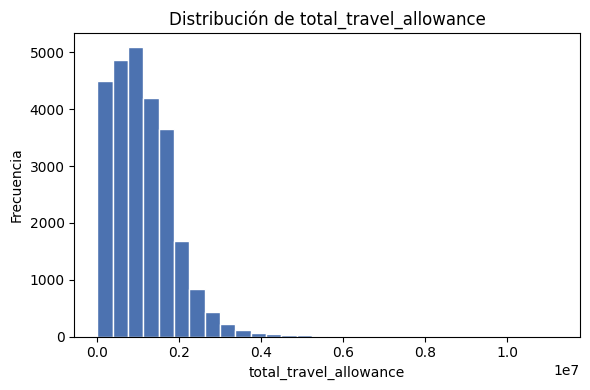

<Figure size 600x400 with 0 Axes>

(array([1.163e+03, 1.467e+03, 7.056e+03, 7.140e+02, 6.633e+03, 5.840e+02,
        3.127e+03, 5.360e+02, 2.921e+03, 7.210e+02, 1.670e+02, 1.530e+02,
        1.400e+01, 8.800e+01, 7.000e+00, 1.060e+02, 1.200e+01, 1.320e+02,
        0.000e+00, 9.800e+01, 0.000e+00, 0.000e+00, 0.000e+00, 1.300e+01,
        0.000e+00, 2.100e+01, 5.000e+00, 0.000e+00, 0.000e+00, 1.500e+01]),
 array([ 0.5       ,  0.98333333,  1.46666667,  1.95      ,  2.43333333,
         2.91666667,  3.4       ,  3.88333333,  4.36666667,  4.85      ,
         5.33333333,  5.81666667,  6.3       ,  6.78333333,  7.26666667,
         7.75      ,  8.23333333,  8.71666667,  9.2       ,  9.68333333,
        10.16666667, 10.65      , 11.13333333, 11.61666667, 12.1       ,
        12.58333333, 13.06666667, 13.55      , 14.03333333, 14.51666667,
        15.        ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de commission_days')

Text(0.5, 0, 'commission_days')

Text(0, 0.5, 'Frecuencia')

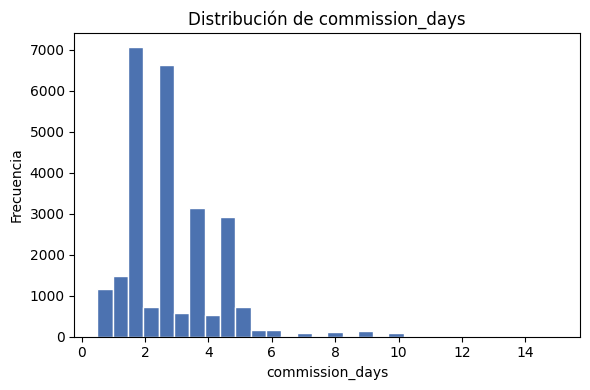

<Figure size 600x400 with 0 Axes>

(array([1.0903e+04, 5.7320e+03, 3.5570e+03, 2.3010e+03, 2.7860e+03,
        3.6000e+02, 5.7000e+01, 8.0000e+00, 1.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.1000e+01, 4.0000e+00, 4.0000e+00, 2.8000e+01]),
 array([   0.        ,  227.24760333,  454.49520667,  681.74281   ,
         908.99041333, 1136.23801667, 1363.48562   , 1590.73322333,
        1817.98082667, 2045.22843   , 2272.47603333, 2499.72363667,
        2726.97124   , 2954.21884333, 3181.46644667, 3408.71405   ,
        3635.96165333, 3863.20925667, 4090.45686   , 4317.70446333,
        4544.95206667, 4772.19967   , 4999.44727333, 5226.69487667,
        5453.94248   , 5681.19008333, 5908.43768667, 6135.68529   ,
        6362.93289333, 6590.18049667, 6817.4281    ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de distance_km')

Text(0.5, 0, 'distance_km')

Text(0, 0.5, 'Frecuencia')

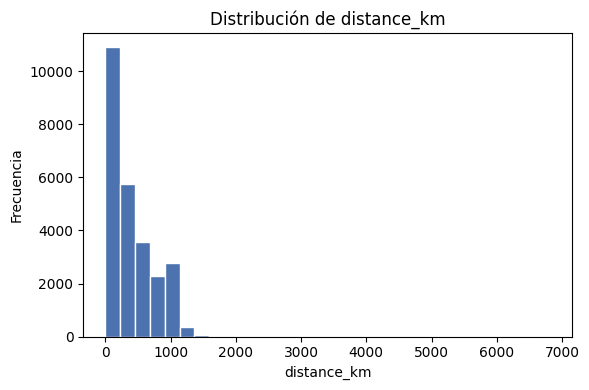

<Figure size 600x400 with 0 Axes>

(array([ 161.,  242.,  432.,  603.,  919.,  978.,  942., 1071., 1112.,
         929.,  986.,  995.,  801.,  669.,  588.,  697.,  750.,  758.,
         740.,  776., 1146., 1413., 1435., 1262., 1212., 1028.,  977.,
         936.,  625.,  570.]),
 array([0.01 , 0.043, 0.076, 0.109, 0.142, 0.175, 0.208, 0.241, 0.274,
        0.307, 0.34 , 0.373, 0.406, 0.439, 0.472, 0.505, 0.538, 0.571,
        0.604, 0.637, 0.67 , 0.703, 0.736, 0.769, 0.802, 0.835, 0.868,
        0.901, 0.934, 0.967, 1.   ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de dept_budget_execution_pct')

Text(0.5, 0, 'dept_budget_execution_pct')

Text(0, 0.5, 'Frecuencia')

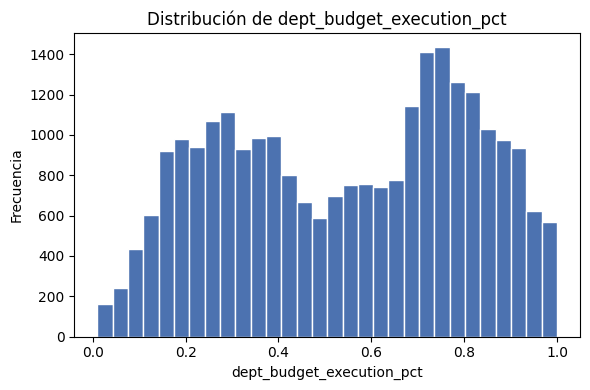

<Figure size 600x400 with 0 Axes>

(array([5.6430e+03, 1.2196e+04, 3.7740e+03, 1.7180e+03, 1.6640e+03,
        3.4100e+02, 1.4800e+02, 7.3000e+01, 4.6000e+01, 4.6000e+01,
        2.2000e+01, 2.4000e+01, 1.8000e+01, 1.8000e+01, 9.0000e+00,
        3.0000e+00, 3.0000e+00, 0.0000e+00, 2.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([      0. ,  250864.2,  501728.4,  752592.6, 1003456.8, 1254321. ,
        1505185.2, 1756049.4, 2006913.6, 2257777.8, 2508642. , 2759506.2,
        3010370.4, 3261234.6, 3512098.8, 3762963. , 4013827.2, 4264691.4,
        4515555.6, 4766419.8, 5017284. , 5268148.2, 5519012.4, 5769876.6,
        6020740.8, 6271605. , 6522469.2, 6773333.4, 7024197.6, 7275061.8,
        7525926. ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de daily_allowance_rate')

Text(0.5, 0, 'daily_allowance_rate')

Text(0, 0.5, 'Frecuencia')

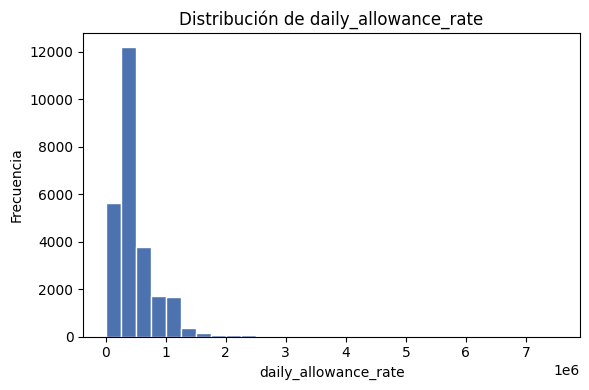

<Figure size 600x400 with 0 Axes>

(array([2.5416e+04, 6.1000e+01, 2.5000e+01, 1.7000e+01, 1.2000e+01,
        2.0000e+01, 9.0000e+00, 2.2000e+01, 9.0000e+00, 2.0000e+01,
        2.0000e+01, 1.3000e+01, 1.1000e+01, 1.4000e+01, 1.9000e+01,
        8.0000e+00, 1.4000e+01, 1.2000e+01, 4.0000e+00, 8.0000e+00,
        4.0000e+00, 7.0000e+00, 1.0000e+00, 2.0000e+00, 0.0000e+00,
        3.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([      0.        ,  110488.96666667,  220977.93333333,
         331466.9       ,  441955.86666667,  552444.83333333,
         662933.8       ,  773422.76666667,  883911.73333333,
         994400.7       , 1104889.66666667, 1215378.63333333,
        1325867.6       , 1436356.56666667, 1546845.53333333,
        1657334.5       , 1767823.46666667, 1878312.43333333,
        1988801.4       , 2099290.36666667, 2209779.33333333,
        2320268.3       , 2430757.26666667, 2541246.23333333,
        2651735.2       , 2762224.16666667, 2872713.13333333,
        2983202.1       , 309369

Text(0.5, 1.0, 'Distribución de allowance_per_km')

Text(0.5, 0, 'allowance_per_km')

Text(0, 0.5, 'Frecuencia')

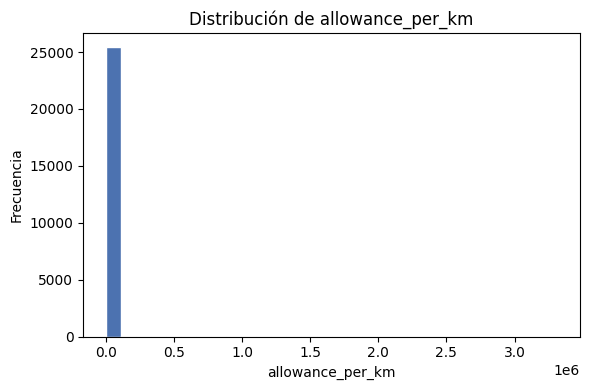

<Figure size 600x400 with 0 Axes>

(array([  133.,     0.,     0.,     0.,     0.,   453.,   199.,     0.,
            0.,   398.,     0.,     0.,     0.,   247.,     0.,     0.,
            0.,     0.,     0.,   498.,     0.,   123.,     0.,     0.,
        15632.,     0.,  7749.,     0.,     0.,   321.]),
 array([      0.  ,   45023.68,   90047.36,  135071.04,  180094.72,
         225118.4 ,  270142.08,  315165.76,  360189.44,  405213.12,
         450236.8 ,  495260.48,  540284.16,  585307.84,  630331.52,
         675355.2 ,  720378.88,  765402.56,  810426.24,  855449.92,
         900473.6 ,  945497.28,  990520.96, 1035544.64, 1080568.32,
        1125592.  , 1170615.68, 1215639.36, 1260663.04, 1305686.72,
        1350710.4 ]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Distribución de purpose_expense_profile')

Text(0.5, 0, 'purpose_expense_profile')

Text(0, 0.5, 'Frecuencia')

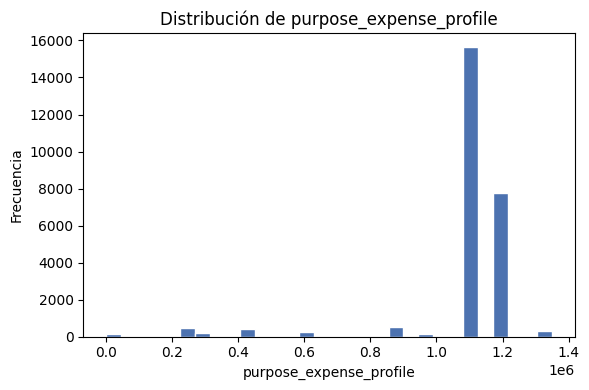

<Figure size 600x400 with 0 Axes>

(array([4.902e+03, 5.147e+03, 5.077e+03, 4.069e+03, 3.531e+03, 1.550e+03,
        7.580e+02, 3.750e+02, 1.700e+02, 6.400e+01, 4.400e+01, 2.600e+01,
        1.800e+01, 1.100e+01, 6.000e+00, 3.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([       0.        ,   373991.26666667,   747982.53333333,
         1121973.8       ,  1495965.06666667,  1869956.33333333,
         2243947.6       ,  2617938.86666667,  2991930.13333333,
         3365921.4       ,  3739912.66666667,  4113903.93333333,
         4487895.2       ,  4861886.46666667,  5235877.73333333,
         5609869.        ,  5983860.26666667,  6357851.53333333,
         6731842.8       ,  7105834.06666667,  7479825.33333333,
         7853816.6       ,  8227807.86666667,  8601799.13333333,
         8975790.4       ,  9349781.66666667,  9723772.93333333,
        10097764.2       , 10471755.4666666

Text(0.5, 1.0, 'Distribución de multi_dest_cost_ratio')

Text(0.5, 0, 'multi_dest_cost_ratio')

Text(0, 0.5, 'Frecuencia')

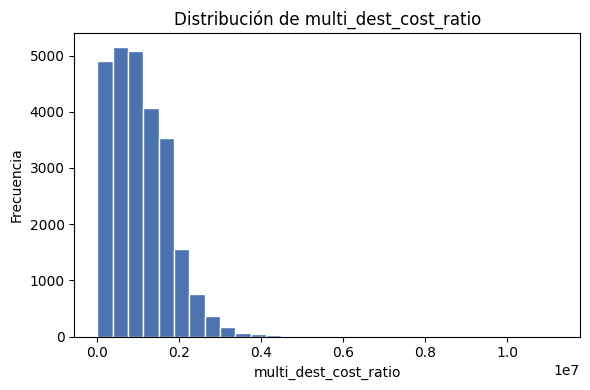

<Figure size 400x300 with 0 Axes>

<Axes: xlabel='is_contractor'>

Text(0.5, 1.0, 'Distribución de is_contractor')

Text(0.5, 0, 'is_contractor')

Text(0, 0.5, 'Frecuencia')

(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

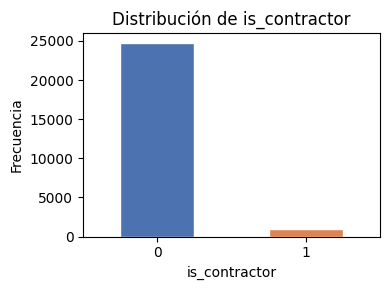

<Figure size 400x300 with 0 Axes>

<Axes: xlabel='had_travel_incidents'>

Text(0.5, 1.0, 'Distribución de had_travel_incidents')

Text(0.5, 0, 'had_travel_incidents')

Text(0, 0.5, 'Frecuencia')

(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

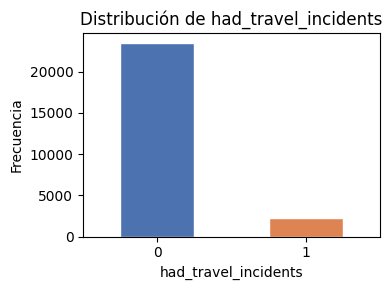

<Figure size 400x300 with 0 Axes>

<Axes: xlabel='return_trip_included'>

Text(0.5, 1.0, 'Distribución de return_trip_included')

Text(0.5, 0, 'return_trip_included')

Text(0, 0.5, 'Frecuencia')

(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

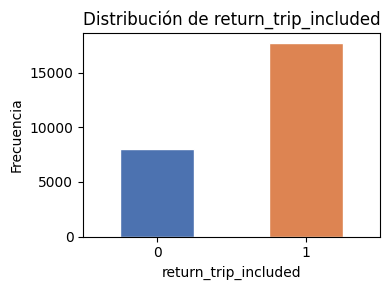

<Figure size 400x300 with 0 Axes>

<Axes: xlabel='requires_per_diem'>

Text(0.5, 1.0, 'Distribución de requires_per_diem')

Text(0.5, 0, 'requires_per_diem')

Text(0, 0.5, 'Frecuencia')

(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

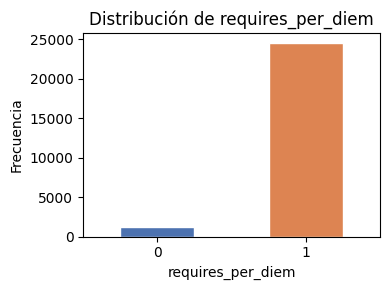

<Figure size 400x300 with 0 Axes>

<Axes: xlabel='is_fiscal_year_end'>

Text(0.5, 1.0, 'Distribución de is_fiscal_year_end')

Text(0.5, 0, 'is_fiscal_year_end')

Text(0, 0.5, 'Frecuencia')

(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

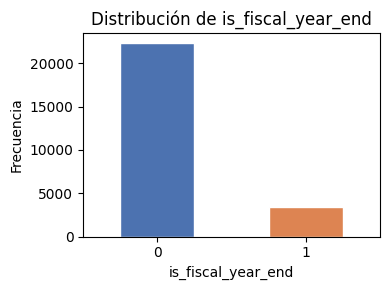

<Figure size 400x300 with 0 Axes>

<Axes: xlabel='is_weekend_departure'>

Text(0.5, 1.0, 'Distribución de is_weekend_departure')

Text(0.5, 0, 'is_weekend_departure')

Text(0, 0.5, 'Frecuencia')

(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

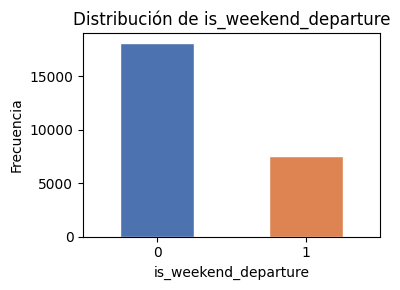

<Figure size 400x300 with 0 Axes>

<Axes: xlabel='is_multi_destination'>

Text(0.5, 1.0, 'Distribución de is_multi_destination')

Text(0.5, 0, 'is_multi_destination')

Text(0, 0.5, 'Frecuencia')

(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

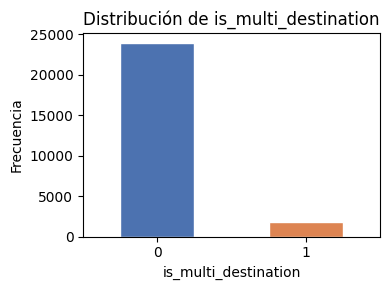

<Figure size 500x300 with 0 Axes>

<Axes: xlabel='position_level'>

Text(0.5, 1.0, 'Distribución de position_level')

Text(0.5, 0, 'position_level')

Text(0, 0.5, 'Frecuencia')

(array([0, 1, 2, 3]),
 [Text(0, 0, '1.0'), Text(1, 0, '2.0'), Text(2, 0, '3.0'), Text(3, 0, '4.0')])

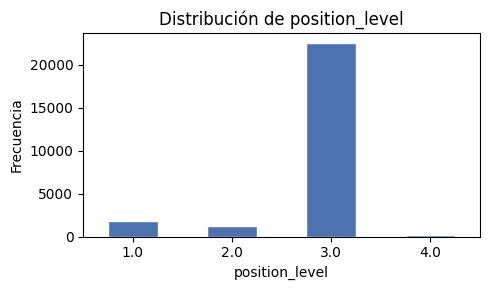

<Figure size 500x300 with 0 Axes>

<Axes: xlabel='destination_count'>

Text(0.5, 1.0, 'Distribución de destination_count')

Text(0.5, 0, 'destination_count')

Text(0, 0.5, 'Frecuencia')

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, '1'),
  Text(1, 0, '2'),
  Text(2, 0, '3'),
  Text(3, 0, '4'),
  Text(4, 0, '5'),
  Text(5, 0, '6')])

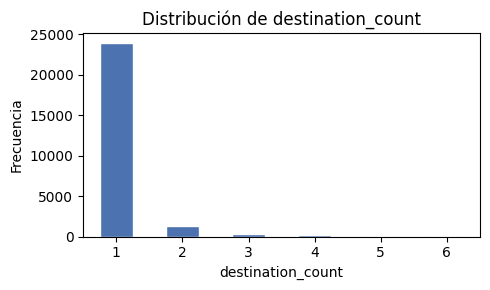

<Figure size 500x300 with 0 Axes>

<Axes: xlabel='prior_authorizations_required'>

Text(0.5, 1.0, 'Distribución de prior_authorizations_required')

Text(0.5, 0, 'prior_authorizations_required')

Text(0, 0.5, 'Frecuencia')

(array([0, 1, 2]), [Text(0, 0, '1'), Text(1, 0, '2'), Text(2, 0, '3')])

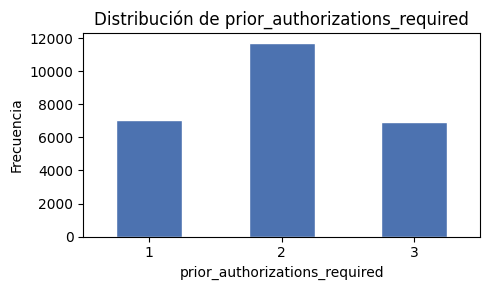

<Figure size 500x300 with 0 Axes>

<Axes: xlabel='travel_month'>

Text(0.5, 1.0, 'Distribución de travel_month')

Text(0.5, 0, 'travel_month')

Text(0, 0.5, 'Frecuencia')

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]),
 [Text(0, 0, '1'),
  Text(1, 0, '2'),
  Text(2, 0, '3'),
  Text(3, 0, '4'),
  Text(4, 0, '5'),
  Text(5, 0, '6'),
  Text(6, 0, '7'),
  Text(7, 0, '8'),
  Text(8, 0, '9'),
  Text(9, 0, '10'),
  Text(10, 0, '11'),
  Text(11, 0, '12')])

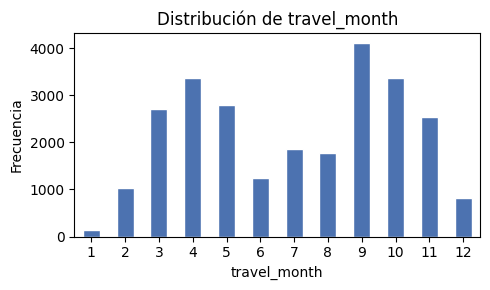

<Figure size 500x300 with 0 Axes>

<Axes: xlabel='travel_quarter'>

Text(0.5, 1.0, 'Distribución de travel_quarter')

Text(0.5, 0, 'travel_quarter')

Text(0, 0.5, 'Frecuencia')

(array([0, 1, 2, 3]),
 [Text(0, 0, '1'), Text(1, 0, '2'), Text(2, 0, '3'), Text(3, 0, '4')])

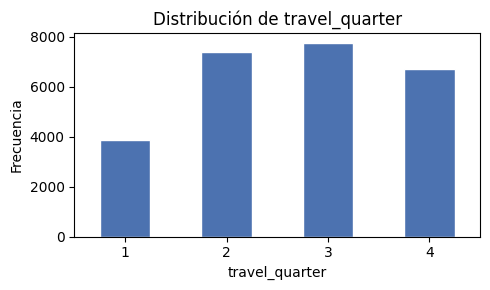

<Figure size 500x300 with 0 Axes>

<Axes: xlabel='travel_year'>

Text(0.5, 1.0, 'Distribución de travel_year')

Text(0.5, 0, 'travel_year')

Text(0, 0.5, 'Frecuencia')

(array([0, 1, 2, 3]),
 [Text(0, 0, '2022'),
  Text(1, 0, '2023'),
  Text(2, 0, '2024'),
  Text(3, 0, '2025')])

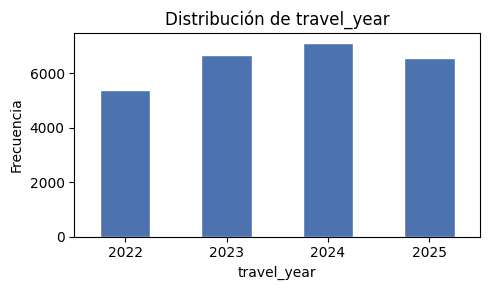

<Figure size 500x300 with 0 Axes>

<Axes: xlabel='position_seniority_index'>

Text(0.5, 1.0, 'Distribución de position_seniority_index')

Text(0.5, 0, 'position_seniority_index')

Text(0, 0.5, 'Frecuencia')

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, '0.5'),
  Text(1, 0, '1.0'),
  Text(2, 0, '1.5'),
  Text(3, 0, '2.0'),
  Text(4, 0, '3.0'),
  Text(5, 0, '4.0')])

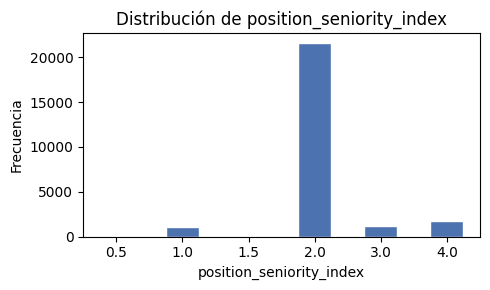

<Figure size 500x300 with 0 Axes>

<Axes: xlabel='advance_booking_days'>

Text(0.5, 1.0, 'Distribución de advance_booking_days')

Text(0.5, 0, 'advance_booking_days')

Text(0, 0.5, 'Frecuencia')

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19]),
 [Text(0, 0, '1'),
  Text(1, 0, '2'),
  Text(2, 0, '3'),
  Text(3, 0, '4'),
  Text(4, 0, '5'),
  Text(5, 0, '6'),
  Text(6, 0, '7'),
  Text(7, 0, '8'),
  Text(8, 0, '9'),
  Text(9, 0, '10'),
  Text(10, 0, '11'),
  Text(11, 0, '12'),
  Text(12, 0, '13'),
  Text(13, 0, '14'),
  Text(14, 0, '15'),
  Text(15, 0, '16'),
  Text(16, 0, '17'),
  Text(17, 0, '18'),
  Text(18, 0, '19'),
  Text(19, 0, '20')])

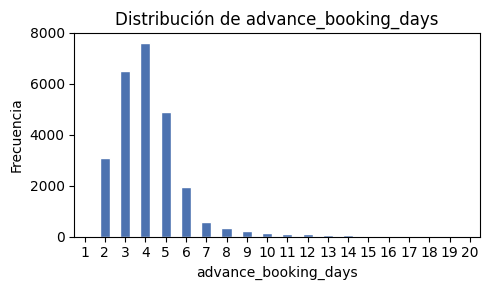

In [ ]:
## Distribución de variables continuas
excluir_hist = ids + flags + cats_cod + ['log_total_allowance']
num_continuas = [col for col in num_auto if col not in excluir_hist]

for col in num_continuas:
    plt.figure(figsize=(6, 4))
    plt.hist(registraduriaDataset[col].dropna(), bins=30, color="#4C72B0", edgecolor="white")
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

## Distribución de flags (barras 0/1)
for col in flags:
    plt.figure(figsize=(4, 3))
    registraduriaDataset[col].value_counts().sort_index().plot(
        kind="bar", color=["#4C72B0", "#DD8452"], edgecolor="white"
    )
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## Distribución de categóricas codificadas (barras ordenadas)
for col in cats_cod:
    plt.figure(figsize=(5, 3))
    registraduriaDataset[col].value_counts().sort_index().plot(
        kind="bar", color="#4C72B0", edgecolor="white"
    )
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

Como podemos observar todas las variables categoricas estan notablemente desbalanceadas, salvo spending_tier:

Omitidas por alta cardinalidad: ['city_destination_main']


/tmp/ipykernel_6342/2467084107.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo.values, y=etiquetas, ax=ax, palette="muted", legend=False)


<Axes: >

Text(0.5, 1.0, 'purpose')

Text(0.5, 0, '')

...

Text(0, 0.5, '')

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

Text(0.5, 1.01, 'Distribución de variables categóricas (top 15 por frecuencia)')

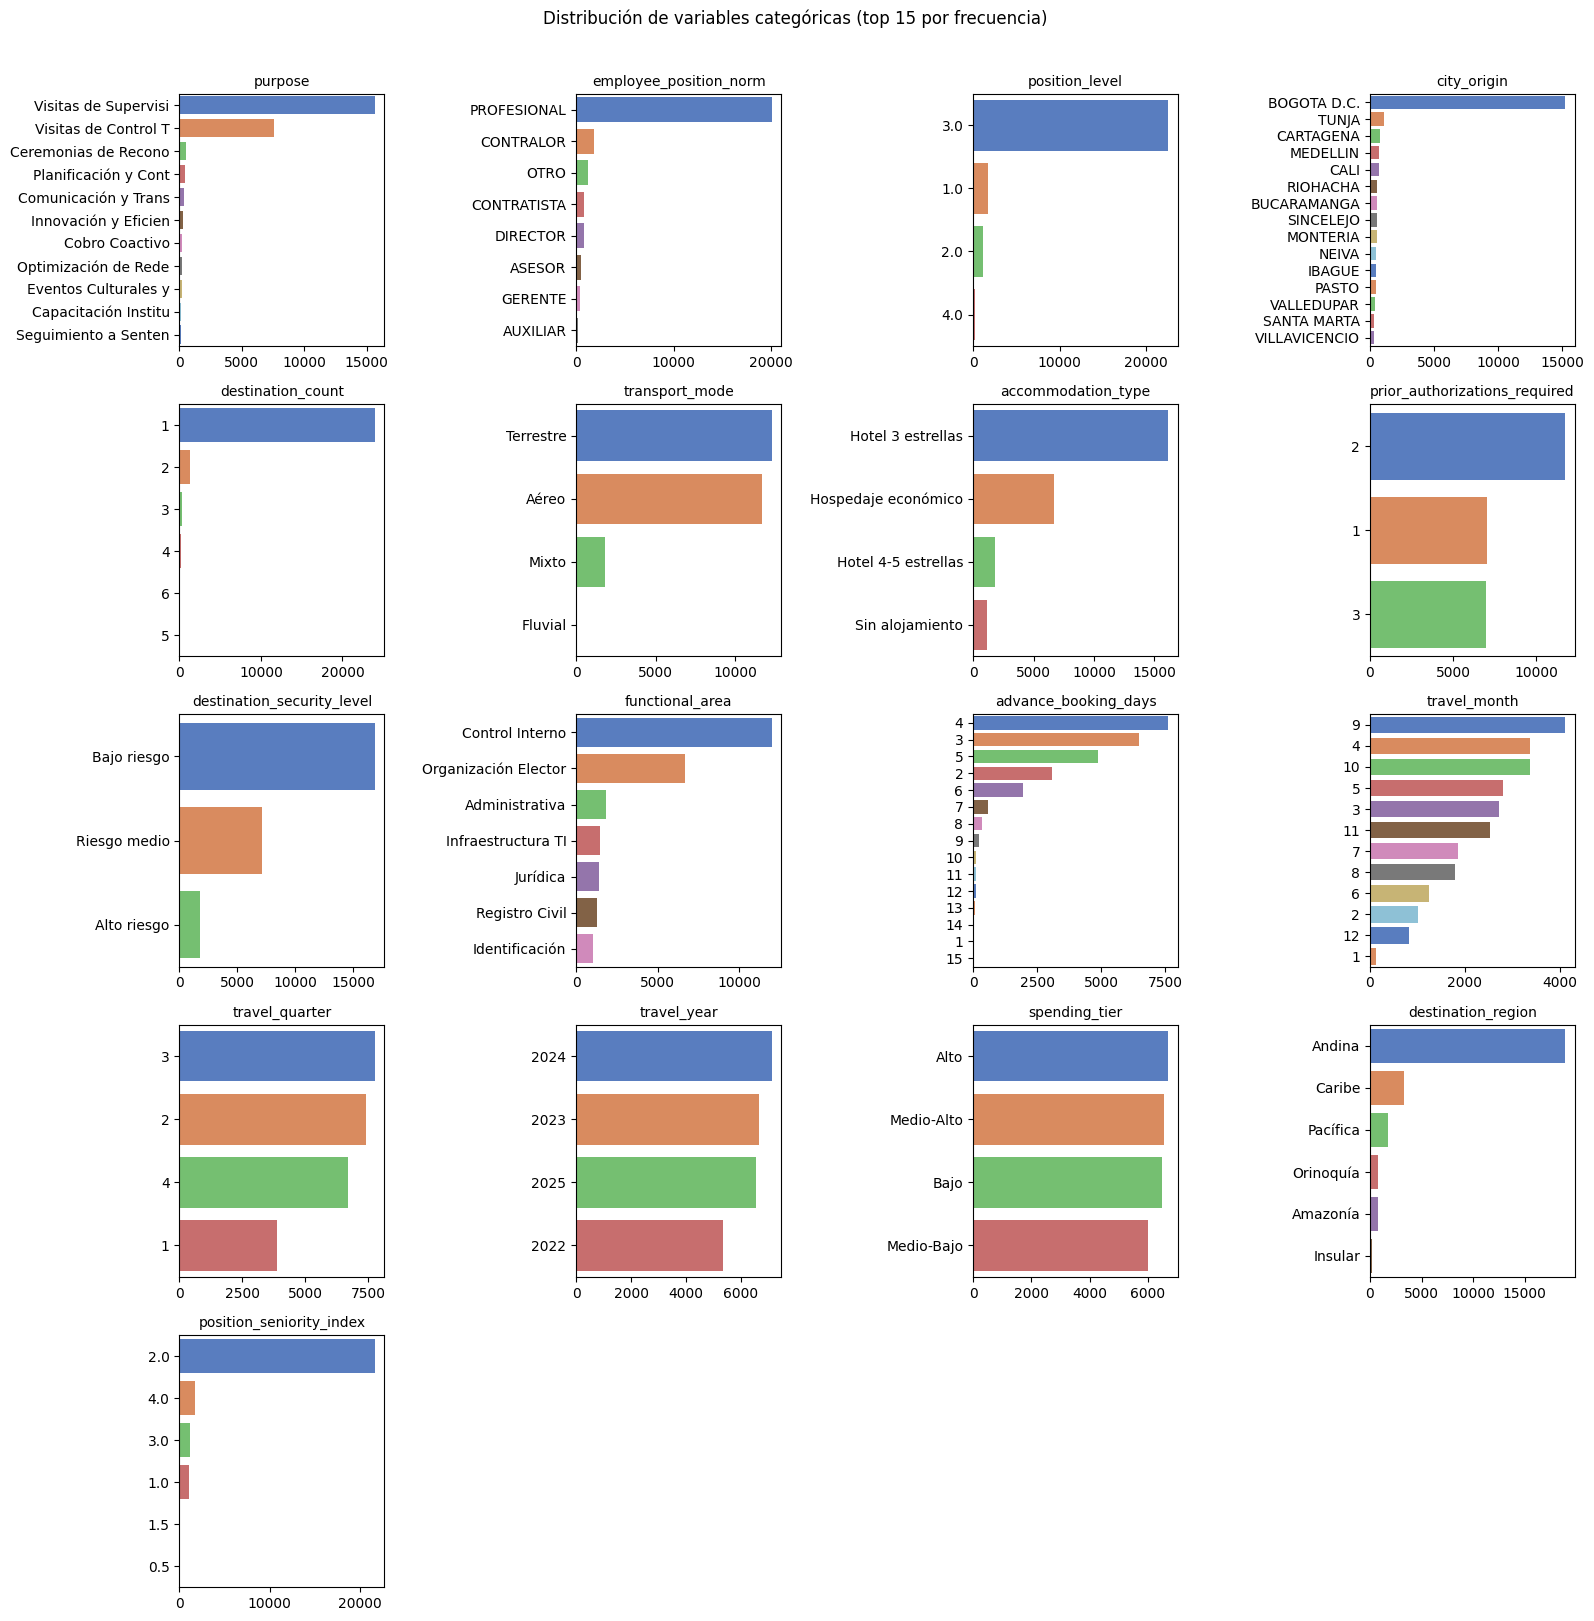

In [ ]:
UMBRAL_CARDINALIDAD = 40
TOP_N = 15

cat_graficar = [c for c in cat_auto if registraduriaDataset[c].nunique() <= UMBRAL_CARDINALIDAD]
cat_omitidas = [c for c in cat_auto if registraduriaDataset[c].nunique() > UMBRAL_CARDINALIDAD]
print("Omitidas por alta cardinalidad:", cat_omitidas)

ncols = 4
nrows = int(np.ceil(len(cat_graficar) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, cat_graficar):
    conteo = registraduriaDataset[col].value_counts().head(TOP_N)
    etiquetas = [str(v)[:20] for v in conteo.index]
    sns.barplot(x=conteo.values, y=etiquetas, ax=ax, palette="muted", legend=False)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[len(cat_graficar):]:
    ax.axis("off")

fig.suptitle("Distribución de variables categóricas (top 15 por frecuencia)", y=1.01)
fig.tight_layout()
plt.show()

## 2.5. Correlación entre las variables
Variables con correlación:

| Variable 1                | Variable 2               | Correlación |
| ------------------------- | ------------------------ | ----------- |
| dept_budget_execution_pct | travel_month             | **0.99**    |
| dept_budget_execution_pct | travel_quarter           | **0.95**    |
| travel_month              | travel_quarter           | **0.96**    |
| position_level            | position_seniority_index | **-0.95**   |
| destination_count         | is_multi_destination     | **0.86**    |
| total_travel_allowance    | multi_dest_cost_ratio    | **0.94**    |
| total_travel_allowance        | prior_authorizations_required | 0.56        |
| total_travel_allowance        | daily_allowance_rate          | 0.53        |
| total_travel_allowance        | log_total_allowance           | 0.53        |
| daily_allowance_rate          | multi_dest_cost_ratio         | 0.54        |
| prior_authorizations_required | multi_dest_cost_ratio         | 0.54        |
| travel_month                  | is_fiscal_year_end            | 0.55        |
| travel_quarter                | is_fiscal_year_end            | 0.50        |

Variables con correlación que son derivadas de otras variables:

| Variable 1                  | Variable 2                 | Correlación |
| --------------------------- | -------------------------- | ----------- |
| `travel_month`              | `travel_quarter`           | 0.96        |
| `dept_budget_execution_pct` | `travel_month`             | 0.99        |
| `dept_budget_execution_pct` | `travel_quarter`           | 0.95        |
| `position_level`            | `position_seniority_index` | -0.95       |
| `destination_count`         | `is_multi_destination`     | 0.86        |
| `total_travel_allowance`    | `multi_dest_cost_ratio`    | 0.94        |
| `total_travel_allowance`    | `log_total_allowance`      | 0.53        |



<Axes: >

Text(0.5, 1.0, 'Correlación entre variables numéricas continuas')

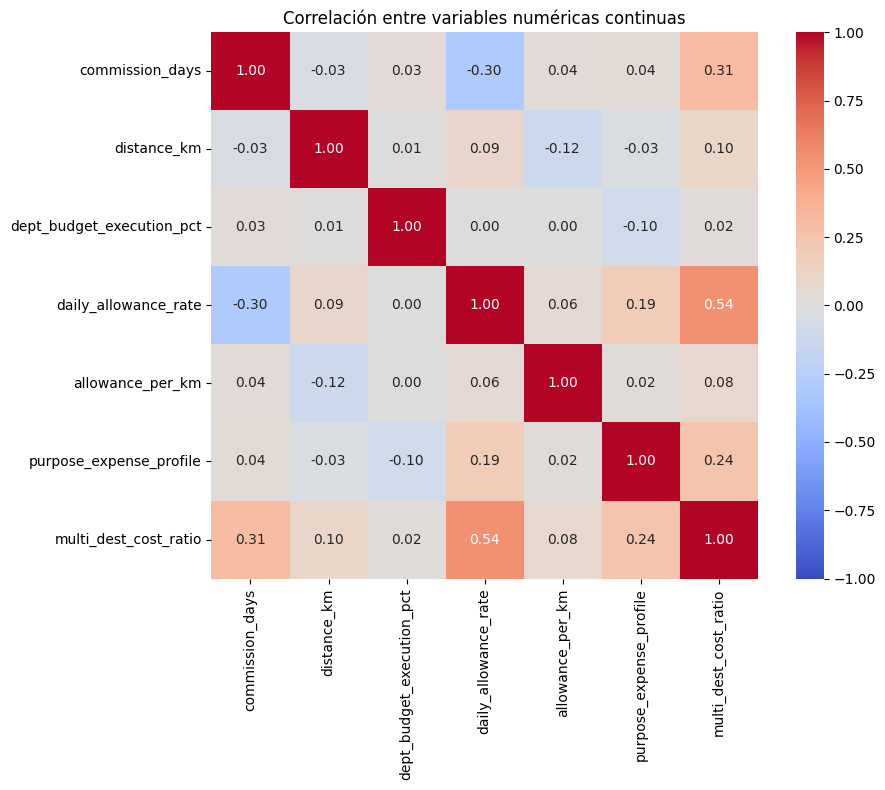

In [ ]:
## Correlación entre variables numéricas continuas
## Se excluyen flags, cats_cod, IDs y variables derivadas del target
excluir_corr = ids + flags + cats_cod + ['log_total_allowance', 'total_travel_allowance']
num_continuas_corr = [col for col in num_auto if col not in excluir_corr]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    registraduriaDataset[num_continuas_corr].corr(),
    annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, square=True, ax=ax
)
ax.set_title("Correlación entre variables numéricas continuas")
fig.tight_layout()
plt.show()

## 2.6. Valores faltantes (y en nuestro caso valores financieros y de distancias que son iguales a 0)



In [ ]:
## Contamos cuantos valores faltan en cada columna: en total y en porcentaje
faltantes = registraduriaDataset.isnull().sum()
faltantes_pct = (faltantes / len(registraduriaDataset) * 100).round(1)

## Identificar el procentaje de las columans con 0 para las probables variables objetico
registraduriaDataset[[
    "total_travel_allowance", "distance_km", "daily_allowance_rate",
    "allowance_per_km", "multi_dest_cost_ratio", "log_total_allowance"
]].eq(0).agg(['sum', 'mean']).T.mul([1, 100]).round(1).set_axis(['total_ceros', 'porcentaje_ceros (%)'], axis=1)

## Mostramos solo las columnas que SI tienen huecos, ordenadas de mayor a menor
resumen = pd.DataFrame({"Faltantes": faltantes, "%": faltantes_pct})
resumen[resumen["Faltantes"] > 0].sort_values("Faltantes", ascending=False)

,total_ceros,porcentaje_ceros (%)
total_travel_allowance,1195.0,4.6
distance_km,375.0,1.5
daily_allowance_rate,1195.0,4.6
allowance_per_km,1195.0,4.6
multi_dest_cost_ratio,1195.0,4.6
log_total_allowance,1195.0,4.6


,Faltantes,%


### 2.6.1. Revision de ceros en la columna total_travel_allowance:

Evaluamos los ceros que contiene esta columna para ver si existe una dinamica especifica relacionada a la existencia de dichos valores (por ejemplo que las visitas sean de menos de un día o que sean a la misma ciudad).

Se encuentra que hay 1195 filas cuyo gasto de viaje es cero y que son comisiones de varios dias y con origenes y destinos diferentes, por lo tanto lo consideramos un error que podríamos remediar **imputando los datos con alguna de las tecnicas aprendidas en clase**.

Es importante resaltar que estos valores en cero corresponden a los valores en cero evidenciados en las columnas:
- *daily_allowance_rate*
- *allowance_per_km*
- *multi_dest_cost_ratio*
- *log_total_travel_allowance*

In [ ]:
reg_ceros = registraduriaDataset[registraduriaDataset['total_travel_allowance'] == 0]
reg_ceros

,viatico_id,commission_request_id,total_travel_allowance,purpose,full_date,commission_days,employee_position_norm,position_level,city_origin,city_destination_main,...,travel_year,is_fiscal_year_end,is_weekend_departure,spending_tier,destination_region,position_seniority_index,purpose_expense_profile,is_multi_destination,multi_dest_cost_ratio,log_total_allowance
35,24288,2412312,0,Visitas de Supervisión Contractual,2022-02-05,1.5,PROFESIONAL,3.0,BOGOTA D.C.,PAZ - ARIPORO,...,2022,0,1,Bajo,Andina,2.0,1107881.0,0,0.0,0.0
43,22382,2410406,0,Visitas de Supervisión Contractual,2022-02-06,4.5,PROFESIONAL,3.0,BOGOTA D.C.,IBAGUE,...,2022,0,1,Bajo,Andina,2.0,1107881.0,0,0.0,0.0
52,16666,2404690,0,Visitas de Supervisión Contractual,2022-02-07,2.5,PROFESIONAL,3.0,BOGOTA D.C.,SANTA MARTA,...,2022,0,0,Bajo,Caribe,2.0,1107881.0,0,0.0,0.0
56,25287,2413311,0,Visitas de Supervisión Contractual,2022-02-08,2.5,PROFESIONAL,3.0,BOGOTA D.C.,VILLETA,...,2022,0,0,Bajo,Andina,2.0,1107881.0,0,0.0,0.0
57,21752,2409776,0,Visitas de Supervisión Contractual,2022-02-09,1.5,PROFESIONAL,3.0,NEIVA,SABANALARGA,...,2022,0,0,Bajo,Caribe,2.0,1107881.0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25734,24440,2412464,0,Visitas de Control Técnico,2025-12-26,9.0,PROFESIONAL,3.0,BOGOTA D.C.,TABIO,...,2025,1,0,Bajo,Andina,2.0,1183522.0,0,0.0,0.0
25737,19863,2407887,0,Visitas de Supervisión Contractual,2025-12-27,2.5,PROFESIONAL,3.0,BOGOTA D.C.,PAEZ,...,2025,1,1,Bajo,Andina,2.0,1107881.0,0,0.0,0.0
25740,18672,2406696,0,Visitas de Supervisión Contractual,2025-12-28,3.5,OTRO,3.0,POPAYAN,VALLEDUPAR,...,2025,1,1,Bajo,Caribe,2.0,1107881.0,0,0.0,0.0
25743,20901,2408925,0,Visitas de Control Técnico,2025-12-29,1.5,CONTRALOR,1.0,BOGOTA D.C.,MONTERIA,...,2025,1,0,Bajo,Caribe,4.0,1183522.0,0,0.0,0.0


### 2.6.2. Revision de ceros en la columna distance_km:

Evaluamos los ceros que contiene esta columna para ver si existe una dinamica especifica relacionada a la existencia de dichos valores.

Se encuentra que hay 375 filas cuyo distancia entre las ciudades de origen y destino es cero y que consideramos un error que podríamos remediar **imputando los datos con alguna de las tecnicas aprendidas en clase**.


In [ ]:
reg_ceros = registraduriaDataset[registraduriaDataset['distance_km'] == 0]
reg_ceros

,viatico_id,commission_request_id,total_travel_allowance,purpose,full_date,commission_days,employee_position_norm,position_level,city_origin,city_destination_main,...,travel_year,is_fiscal_year_end,is_weekend_departure,spending_tier,destination_region,position_seniority_index,purpose_expense_profile,is_multi_destination,multi_dest_cost_ratio,log_total_allowance
400,22343,2410367,1868481,Visitas de Supervisión Contractual,2022-03-11,3.5,PROFESIONAL,3.0,BOGOTA D.C.,SAN ONOFRE,...,2022,0,0,Alto,Andina,2.0,1107881.0,0,1868481.0,14.440637
440,24318,2412342,1608113,Visitas de Supervisión Contractual,2022-03-12,5.5,PROFESIONAL,3.0,BOGOTA D.C.,EL - DE BOLIVAR,...,2022,0,1,Alto,Andina,2.0,1107881.0,0,1608113.0,14.290573
448,25854,2413878,1834567,Visitas de Control Técnico,2022-03-13,2.5,PROFESIONAL,3.0,BOGOTA D.C.,PIOJO,...,2022,0,1,Alto,Andina,2.0,1183522.0,0,1834567.0,14.422320
490,23703,2411727,1042273,Visitas de Control Técnico,2022-03-17,2.5,PROFESIONAL,3.0,MEDELLIN,EL COPEY,...,2022,0,0,Medio-Alto,Andina,2.0,1183522.0,0,1042273.0,13.856915
592,22352,2410376,1781906,Visitas de Supervisión Contractual,2022-03-22,1.5,PROFESIONAL,3.0,BOGOTA D.C.,BUENAVENTURA,...,2022,0,0,Alto,Pacífica,2.0,1107881.0,0,1781906.0,14.393195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25230,21115,2409139,258072,Comunicación y Transparencia Territorial,2025-11-17,4.5,CONTRATISTA,3.0,BOGOTA D.C.,S.JUAN NEPOMUCENO,...,2025,1,0,Bajo,Andina,1.0,441603.5,0,258072.0,12.460998
25323,16830,2404854,1894268,Visitas de Control Técnico,2025-11-19,2.0,CONTRATISTA,3.0,PEREIRA,EL COPEY,...,2025,1,0,Alto,Andina,1.0,1183522.0,0,1894268.0,14.454344
25383,16793,2404817,1311098,Visitas de Control Técnico,2025-11-23,10.0,PROFESIONAL,3.0,BOGOTA D.C.,GIRON,...,2025,1,1,Medio-Alto,Andina,2.0,1183522.0,0,1311098.0,14.086376
25530,23328,2411352,565989,Visitas de Supervisión Contractual,2025-11-29,1.5,PROFESIONAL,3.0,RIOHACHA,SAN ONOFRE,...,2025,1,1,Medio-Bajo,Andina,2.0,1107881.0,0,565989.0,13.246332


<Axes: >

Text(0.5, 1.0, 'Mapa de Ceros en Variables Financieras y de Distancia (Azul = 0)')

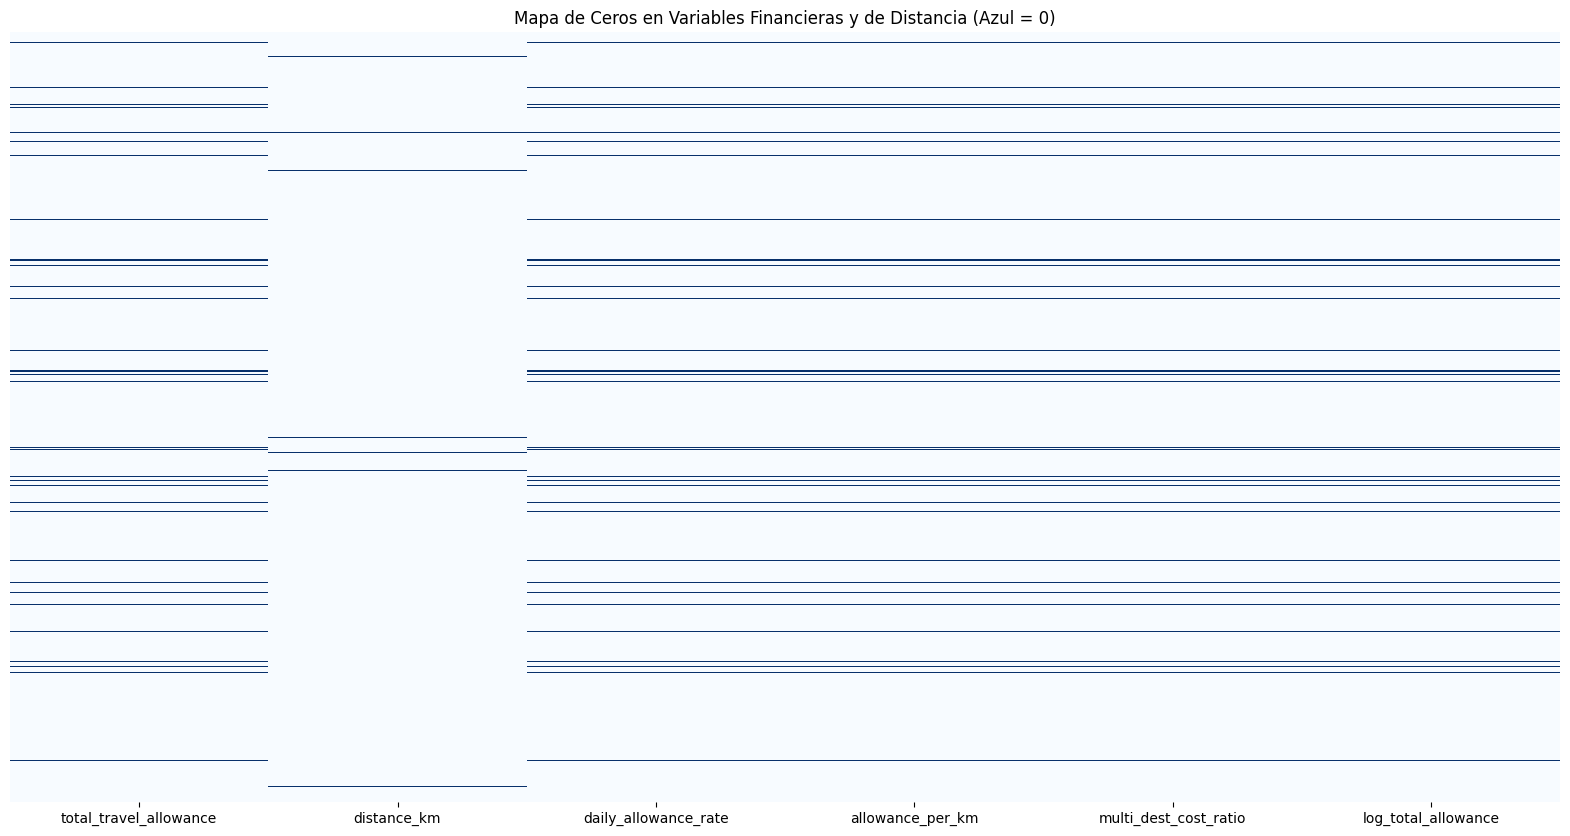

In [ ]:
fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(
    registraduriaDataset[[
        "total_travel_allowance", "distance_km", "daily_allowance_rate",
        "allowance_per_km", "multi_dest_cost_ratio", "log_total_allowance"
    ]].eq(0),
    cbar=False,
    cmap="Blues",
    yticklabels=False,
    ax=ax
)

ax.set_title("Mapa de Ceros en Variables Financieras y de Distancia (Azul = 0)")
plt.show()

# 3. Limpieza antes de la división del dataset

In [ ]:
## Descartar variables de identificación
registraduriaLimpio = registraduriaDataset.drop(columns=["viatico_id", "commission_request_id"])

## Forzar cats_cod a category de texto (Int8/Int16 no son compatibles con OneHotEncoder)
for col in cats_cod:
    if col in registraduriaLimpio.columns:
        registraduriaLimpio[col] = registraduriaLimpio[col].astype(str).astype("category")


In [ ]:
## Llenar con valores nulos aquellas columnas con ceros invalidos

columnas_con_ceros_invalidos = [
    'total_travel_allowance',
    'distance_km',
    'daily_allowance_rate',
    'allowance_per_km',
    'multi_dest_cost_ratio',
    'log_total_allowance'
]

registraduriaLimpio[columnas_con_ceros_invalidos] = (
    registraduriaLimpio[columnas_con_ceros_invalidos]
    .replace(0, np.nan)
)

# 4. Division del dataset para el modelo de Clasificación

In [ ]:
## Variable objetivo y predictoras
y = registraduriaLimpio['purpose']
predictoras = [c for c in registraduriaLimpio.columns if c != 'purpose']
X = registraduriaLimpio[predictoras]

print("Clases en y:")
print(y.value_counts(dropna=False))
print(f"\nClases únicas: {y.nunique()}")
print(f"NaN en y: {y.isna().sum()}")

Clases en y:
purpose
Visitas de Supervisión Contractual          15632
Visitas de Control Técnico                   7545
Ceremonias de Reconocimiento                  498
Planificación y Control Fiscal                453
Comunicación y Transparencia Territorial      398
Innovación y Eficiencia Pública               321
Cobro Coactivo                                247
Optimización de Redes LAN                     204
Eventos Culturales y Bienestar                199
Capacitación Institucional                    133
Seguimiento a Sentencias                      123
Name: count, dtype: int64

Clases únicas: 11
NaN en y: 0


In [ ]:
## División estratificada para modelo de CLASIFICACION (stratify garantiza proporciones iguales en train y test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]:,} filas")
print(f"Prueba       : {X_test.shape[0]:,} filas")

Entrenamiento: 20,602 filas
Prueba       : 5,151 filas


# 5. Procesamiento post division

In [ ]:
## Definición de listas de columnas para el pipeline
## Construidas después del split para usar solo X_train como referencia

numericas_reales = [
    col for col in X_train.select_dtypes(include='number').columns
    if col not in excluir
]

categoricas = list(dict.fromkeys(
    X_train.select_dtypes(include='category').columns.tolist()
    + cats_cod
))
# Excluir columnas de alta cardinalidad o no útiles para el modelo
categoricas = [c for c in categoricas if c not in ['full_date', 'city_destination_main']]

flags_activas = [col for col in flags if col in X_train.columns]

print("Numéricas continuas :", numericas_reales)
print("Categóricas         :", categoricas)
print("Flags               :", flags_activas)

Numéricas continuas : ['total_travel_allowance', 'commission_days', 'distance_km', 'dept_budget_execution_pct', 'daily_allowance_rate', 'allowance_per_km', 'purpose_expense_profile', 'multi_dest_cost_ratio', 'log_total_allowance']
Categóricas         : ['employee_position_norm', 'position_level', 'city_origin', 'destination_count', 'transport_mode', 'accommodation_type', 'prior_authorizations_required', 'destination_security_level', 'functional_area', 'advance_booking_days', 'travel_month', 'travel_quarter', 'travel_year', 'spending_tier', 'destination_region', 'position_seniority_index']
Flags               : ['is_contractor', 'had_travel_incidents', 'return_trip_included', 'requires_per_diem', 'is_fiscal_year_end', 'is_weekend_departure', 'is_multi_destination']


In [ ]:
## Ramas del preprocesador

rama_numerica = Pipeline([
    ("imputar", SimpleImputer(strategy="median")),  # mediana aprendida solo de train
    ("escalar", StandardScaler()),                  # media 0, desviación 1
])

rama_categorica = Pipeline([
    ("imputar", SimpleImputer(strategy="most_frequent")),
    ("codificar", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# Flags: solo imputar — ya son 0/1, escalar o codificar no aporta nada
rama_flags = Pipeline([
    ("imputar", SimpleImputer(strategy="most_frequent")),
])

preprocesador = ColumnTransformer([
    ("num", rama_numerica,   numericas_reales),
    ("cat", rama_categorica, categoricas),
    ("bin", rama_flags,      flags_activas),
],
remainder="drop"  # descarta full_date, city_destination_main y cualquier otra no declarada
)

preprocesador

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputar',
                                                  SimpleImputer(strategy='median')),
                                                 ('escalar',
                                                  StandardScaler())]),
                                 ['total_travel_allowance', 'commission_days',
                                  'distance_km', 'dept_budget_execution_pct',
                                  'daily_allowance_rate', 'allowance_per_km',
                                  'purpose_expense_profile',
                                  'multi_dest_cost_ratio',
                                  'log_total_allowance']),
                                ('cat',
                                 Pipeline(s...
                                  'functional_area', 'advance_booking_days',
                                  'travel_month', 'travel_quarter',
                                  'travel_year', 'spending_tier',
                                  'destination_region',
                                  'position_seniority_index']),
                                ('bin',
                                 Pipeline(steps=[('imputar',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['is_contractor', 'had_travel_incidents',
                                  'return_trip_included', 'requires_per_diem',
                                  'is_fiscal_year_end', 'is_weekend_departure',
                                  'is_multi_destination'])])

In [ ]:
## Aplicar el preprocesador
## fit_transform sobre train: aprende parámetros (mediana, media, categorías) y transforma
X_train_prep = preprocesador.fit_transform(X_train)

## transform sobre test: aplica los parámetros aprendidos en train (sin reaprender)
X_test_prep = preprocesador.transform(X_test)

print(f"X_train: {X_train.shape}  →  {X_train_prep.shape}")
print(f"X_test : {X_test.shape}  →  {X_test_prep.shape}")

X_train: (20602, 34)  →  (20602, 142)
X_test : (5151, 34)  →  (5151, 142)


In [ ]:
## Verificación: el imputador aprendió de train, no del dataset completo
nombres = preprocesador.get_feature_names_out()
print(f"Columnas tras preprocesar: {len(nombres)}")

print(f"NaN en train preprocesado: {int(np.isnan(X_train_prep).sum())}")
print(f"NaN en test preprocesado : {int(np.isnan(X_test_prep).sum())}")

# Confirmar que la mediana del imputador coincide con la mediana de train (no del dataset completo)
imputador_num = preprocesador.named_transformers_["num"].named_steps["imputar"]
idx_tc = numericas_reales.index("total_travel_allowance")

print(f"\nMediana de total_travel_allowance en TRAIN       : {X_train['total_travel_allowance'].median():,.2f}")
print(f"Mediana de total_travel_allowance en TODO el set : {X['total_travel_allowance'].median():,.2f}")
print(f"Valor aprendido por el imputador                  : {imputador_num.statistics_[idx_tc]:,.2f}")

pd.DataFrame(X_train_prep, columns=nombres, index=X_train.index).head()

Columnas tras preprocesar: 142
NaN en train preprocesado: 0
NaN en test preprocesado : 0

Mediana de total_travel_allowance en TRAIN       : 1,053,947.50
Mediana de total_travel_allowance en TODO el set : 1,049,570.00
Valor aprendido por el imputador                  : 1,053,947.50


,num__total_travel_allowance,num__commission_days,num__distance_km,num__dept_budget_execution_pct,num__daily_allowance_rate,num__allowance_per_km,num__purpose_expense_profile,num__multi_dest_cost_ratio,num__log_total_allowance,cat__employee_position_norm_ASESOR,...,cat__position_seniority_index_2.0,cat__position_seniority_index_3.0,cat__position_seniority_index_4.0,bin__is_contractor,bin__had_travel_incidents,bin__return_trip_included,bin__requires_per_diem,bin__is_fiscal_year_end,bin__is_weekend_departure,bin__is_multi_destination
7557,-0.250685,-0.109029,0.691028,-0.625673,-0.300227,-0.134129,0.507426,-0.180048,0.105860,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
5367,-0.153215,-0.756914,0.102724,1.655338,0.524017,-0.127433,-1.193021,-0.076801,0.188699,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
25739,0.517272,-0.756914,0.444810,1.585585,1.407652,-0.125410,0.112156,0.633425,0.639043,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0
22364,-0.492195,-0.756914,-0.737025,-0.104039,0.077275,-0.087303,0.112155,-0.435872,-0.129102,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
25688,-0.516751,-0.756914,0.112859,1.720921,0.044913,-0.131883,0.112155,-0.461883,-0.155883,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0


## 5.1. Imputación MICE vs Mediana

Comparamos la imputación por mediana (que colapsa todos los valores faltantes al mismo punto) contra MICE (Multivariate Imputation by Chained Equations), que preserva la distribución real usando las relaciones entre variables.

In [ ]:
## Pipeline con MICE en lugar de mediana
rama_numerica_mice = Pipeline([
    ("imputar", IterativeImputer(random_state=42)),
    ("escalar", StandardScaler()),
])

preprocesador_mice = ColumnTransformer([
    ("num", rama_numerica_mice, numericas_reales),
    ("cat", rama_categorica,   categoricas),
    ("bin", rama_flags,        flags_activas),
],
remainder="drop"
)

X_train_mice = preprocesador_mice.fit_transform(X_train)
print(f"Preprocesador con MICE ajustado solo en train → {X_train_mice.shape}")

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Preprocesador con MICE ajustado solo en train → (20602, 142)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


(array([3.73862337e-07, 4.04563374e-07, 5.65698404e-07, 5.71148293e-07,
        4.59788909e-07, 4.45800862e-07, 3.23360038e-07, 1.65131615e-07,
        9.55547080e-08, 5.90404565e-08, 3.74225662e-08, 2.05279126e-08,
        1.18080913e-08, 9.99146186e-09, 5.26822534e-09, 4.54157357e-09,
        4.54157357e-09, 2.54328120e-09, 1.81662943e-09, 1.08997766e-09,
        1.08997766e-09, 0.00000000e+00, 1.81662943e-10, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.81662943e-10, 1.81662943e-10, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.81662943e-10]),
 array([5.39000000e+02, 2.81018975e+05, 5.61498950e+05, 8.41978925e+05,
        1.12245890e+06, 1.40293888e+06, 1.68341885e+06, 1.96389882e+06,
        2.24437880e+06, 2.52485877e+06, 2.80533875e+06, 3.08581872e+06,
        3.36629870e+06, 3.64677867e+06, 3.92725865e+06, 4.2077

(array([0.00000000e+00, 3.90869785e-07, 1.12877349e-06, 6.21008070e-08,
        1.98357283e-06, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00]),
 array([5.39000000e+02, 2.81018975e+05, 5.61498950e+05, 8.41978925e+05,
        1.12245890e+06, 1.40293888e+06, 1.68341885e+06, 1.96389882e+06,
        2.24437880e+06, 2.52485877e+06, 2.80533875e+06, 3.08581872e+06,
        3.36629870e+06, 3.64677867e+06, 3.92725865e+06, 4.2077

Text(0.5, 1.0, 'total_travel_allowance: MICE conserva la forma real; la mediana colapsa a un punto')

Text(0.5, 0, 'total_travel_allowance')

Text(0, 0.5, 'Densidad')

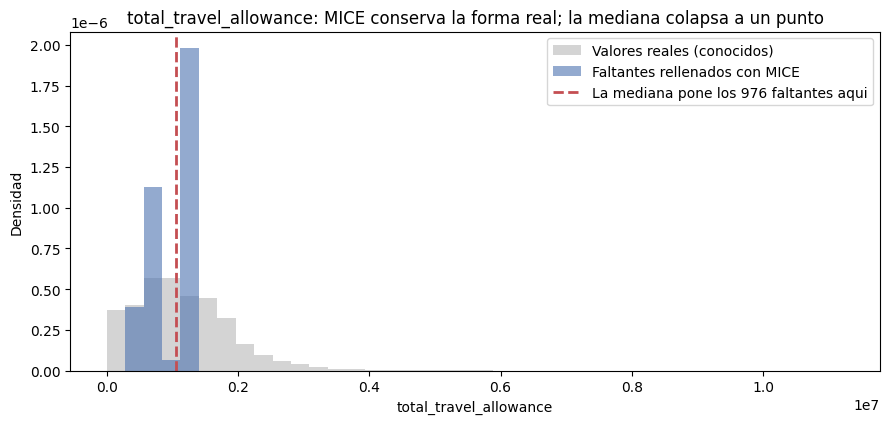

In [ ]:
# Teniendo el entramiento para MICE ejecutamos la imputacion de los datos
faltaban = X_train["total_travel_allowance"].isna()
col_tc = numericas_reales.index("total_travel_allowance")

tc_med  = SimpleImputer(strategy="median").fit_transform(X_train[numericas_reales])[:, col_tc]
tc_mice = IterativeImputer(random_state=42).fit_transform(X_train[numericas_reales])[:, col_tc]

reales        = X_train.loc[~faltaban, "total_travel_allowance"]
imput_mice    = pd.Series(tc_mice, index=X_train.index)[faltaban]
valor_mediana = pd.Series(tc_med,  index=X_train.index)[faltaban].iloc[0]

# Mismos bins para comparar de forma justa, y densidad para comparar la FORMA (no el conteo)
bins = np.linspace(min(reales.min(), imput_mice.min()), max(reales.max(), imput_mice.max()), 41)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(reales,     bins=bins, density=True, alpha=0.5, color="#AAAAAA", label="Valores reales (conocidos)")
ax.hist(imput_mice, bins=bins, density=True, alpha=0.6, color="#4C72B0", label="Faltantes rellenados con MICE")
# La mediana colapsa TODOS los faltantes a un unico valor: lo marcamos con una linea vertical
ax.axvline(valor_mediana, color="#C44E52", linestyle="--", linewidth=2,
           label=f"La mediana pone los {int(faltaban.sum())} faltantes aqui")
ax.set_title("total_travel_allowance: MICE conserva la forma real; la mediana colapsa a un punto")
ax.set_xlabel("total_travel_allowance"); ax.set_ylabel("Densidad"); ax.legend()
fig.tight_layout()
plt.show()

In [ ]:
# Descripcion de los valores reales
print(reales.describe())

count    1.962600e+04
mean     1.156117e+06
std      7.507284e+05
min      5.390000e+02
25%      6.096240e+05
50%      1.053948e+06
75%      1.585438e+06
max      1.121974e+07
Name: total_travel_allowance, dtype: float64


In [ ]:
# Descripcion de los valores de MICE
print(imput_mice.describe())

count    9.760000e+02
mean     9.244200e+05
std      2.894323e+05
min      4.316378e+05
25%      6.124951e+05
50%      1.145729e+06
75%      1.163229e+06
max      1.306520e+06
dtype: float64


In [ ]:
# Ver la correlacion entre variables numericas del dataframe de entranamiento
print(X_train[numericas_reales].corr())

                           total_travel_allowance  commission_days  \
total_travel_allowance                   1.000000         0.430163   
commission_days                          0.430163         1.000000   
distance_km                              0.114211        -0.027082   
dept_budget_execution_pct                0.050183         0.034553   
daily_allowance_rate                     0.482707        -0.321328   
allowance_per_km                         0.065502         0.033850   
purpose_expense_profile                  0.170740         0.046698   
multi_dest_cost_ratio                    0.930659         0.324974   
log_total_allowance                      0.848349         0.342970   

                           distance_km  dept_budget_execution_pct  \
total_travel_allowance        0.114211                   0.050183   
commission_days              -0.027082                   0.034553   
distance_km                   1.000000                   0.007553   
dept_budget_execution_p

In [ ]:
## Evaluación cuantitativa: MAE de mediana vs MICE sobre valores conocidos ocultados

faltaban = X_train["total_travel_allowance"].isna()
base = X_train.loc[~faltaban, numericas_reales].copy()

rng = np.random.default_rng(42)
ocultos = rng.choice(base.index, size=int(0.20 * len(base)), replace=False)
verdaderos = base.loc[ocultos, "total_travel_allowance"].copy()

prueba = base.copy()
prueba.loc[ocultos, "total_travel_allowance"] = np.nan

col_tc = numericas_reales.index("total_travel_allowance")
rell_med  = pd.Series(SimpleImputer(strategy="median").fit_transform(prueba)[:, col_tc], index=base.index).loc[ocultos]
rell_mice = pd.Series(IterativeImputer(random_state=42).fit_transform(prueba)[:, col_tc], index=base.index).loc[ocultos]

mae_med  = (rell_med  - verdaderos).abs().mean()
mae_mice = (rell_mice - verdaderos).abs().mean()
print(f"MAE con MEDIANA : {mae_med:,.0f}")
print(f"MAE con MICE    : {mae_mice:,.0f}")
print(f"MICE reduce el error un {(1 - mae_mice / mae_med) * 100:.0f}% en este dataset.")

MAE con MEDIANA : 579,281
MAE con MICE    : 106,360
MICE reduce el error un 82% en este dataset.


## 5.2 Outliers y transformadas

Detectamos outliers con IQR y Z-score **usando solo los cuartiles y estadísticos de train** para evitar fuga de datos.

In [ ]:
## Detección de outliers por IQR (límites aprendidos solo de train)
Q1 = X_train[numericas_reales].quantile(0.25)
Q3 = X_train[numericas_reales].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_iqr = ((X_train[numericas_reales] < limite_inferior) | (X_train[numericas_reales] > limite_superior)).sum()
print("Outliers detectados por IQR (en train):")
print(outliers_iqr.to_string())

Outliers detectados por IQR (en train):
total_travel_allowance        388
commission_days               397
distance_km                    99
dept_budget_execution_pct       0
daily_allowance_rate         2310
allowance_per_km             1896
purpose_expense_profile      1898
multi_dest_cost_ratio         283
log_total_allowance          1057


In [ ]:
## Detección de outliers por Z-score (media y desviación aprendidas de train)
z = X_train[numericas_reales].apply(lambda col: (col - col.mean()) / col.std())
outliers_z = (z.abs() > 3).sum()
print("Outliers detectados por Z-score > 3 (en train):")
print(outliers_z.to_string())

Outliers detectados por Z-score > 3 (en train):
total_travel_allowance       229
commission_days              326
distance_km                   43
dept_budget_execution_pct      0
daily_allowance_rate         261
allowance_per_km             181
purpose_expense_profile      946
multi_dest_cost_ratio        165
log_total_allowance          191


<Figure size 600x400 with 0 Axes>

{'whiskers': [<matplotlib.lines.Line2D at 0x7c3c16933740>,
 'caps': [<matplotlib.lines.Line2D at 0x7c3c169ef8f0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7c3c16932180>],
 'medians': [<matplotlib.lines.Line2D at 0x7c3c16729460>],
 'fliers': [<matplotlib.lines.Line2D at 0x7c3c1672a6c0>],
 'means': []}

Text(0.5, 1.0, 'Outliers en total_travel_allowance')

([<matplotlib.axis.XTick at 0x7c3c15c044d0>],
 [Text(1, 0, 'total_travel_allowance')])

Text(0, 0.5, 'total_travel_allowance')

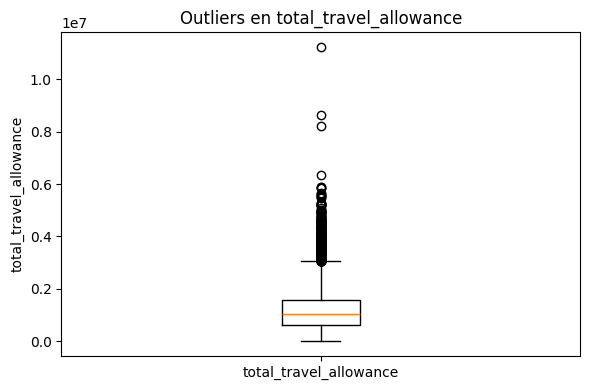

<Figure size 600x400 with 0 Axes>

{'whiskers': [<matplotlib.lines.Line2D at 0x7c3c15eb4080>,
 'caps': [<matplotlib.lines.Line2D at 0x7c3c169e1100>,
 'boxes': [<matplotlib.lines.Line2D at 0x7c3c15eb6900>],
 'medians': [<matplotlib.lines.Line2D at 0x7c3c15d554c0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7c3c158c2db0>],
 'means': []}

Text(0.5, 1.0, 'Outliers en commission_days')

([<matplotlib.axis.XTick at 0x7c3c15e37d70>], [Text(1, 0, 'commission_days')])

Text(0, 0.5, 'commission_days')

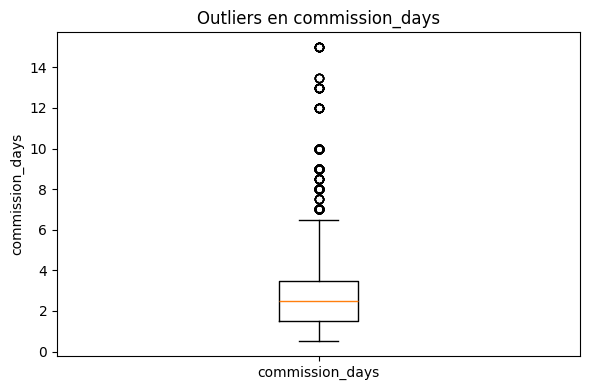

<Figure size 600x400 with 0 Axes>

{'whiskers': [<matplotlib.lines.Line2D at 0x7c3c15736840>,
 'caps': [<matplotlib.lines.Line2D at 0x7c3c15642090>,
 'boxes': [<matplotlib.lines.Line2D at 0x7c3c157363c0>],
 'medians': [<matplotlib.lines.Line2D at 0x7c3c15642ed0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7c3c156431a0>],
 'means': []}

Text(0.5, 1.0, 'Outliers en distance_km')

([<matplotlib.axis.XTick at 0x7c3c16a08980>], [Text(1, 0, 'distance_km')])

Text(0, 0.5, 'distance_km')

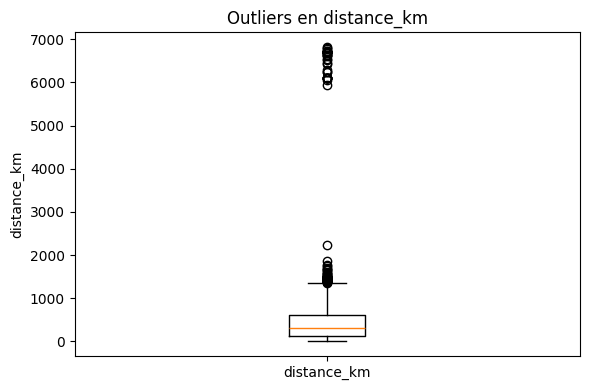

<Figure size 600x400 with 0 Axes>

{'whiskers': [<matplotlib.lines.Line2D at 0x7c3c156dc200>,
 'caps': [<matplotlib.lines.Line2D at 0x7c3c156de330>,
 'boxes': [<matplotlib.lines.Line2D at 0x7c3c156a1460>],
 'medians': [<matplotlib.lines.Line2D at 0x7c3c156de720>],
 'fliers': [<matplotlib.lines.Line2D at 0x7c3c156dc8c0>],
 'means': []}

Text(0.5, 1.0, 'Outliers en dept_budget_execution_pct')

([<matplotlib.axis.XTick at 0x7c3c156a0bc0>],
 [Text(1, 0, 'dept_budget_execution_pct')])

Text(0, 0.5, 'dept_budget_execution_pct')

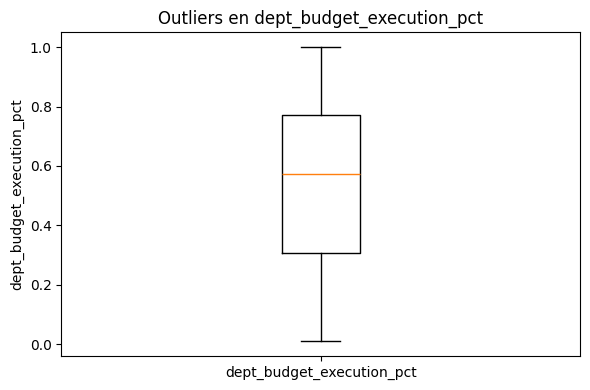

<Figure size 600x400 with 0 Axes>

{'whiskers': [<matplotlib.lines.Line2D at 0x7c3c1552b590>,
 'caps': [<matplotlib.lines.Line2D at 0x7c3c1552ae70>,
 'boxes': [<matplotlib.lines.Line2D at 0x7c3c1552bf50>],
 'medians': [<matplotlib.lines.Line2D at 0x7c3c1552b740>],
 'fliers': [<matplotlib.lines.Line2D at 0x7c3c1552aba0>],
 'means': []}

Text(0.5, 1.0, 'Outliers en daily_allowance_rate')

([<matplotlib.axis.XTick at 0x7c3c15509c70>],
 [Text(1, 0, 'daily_allowance_rate')])

Text(0, 0.5, 'daily_allowance_rate')

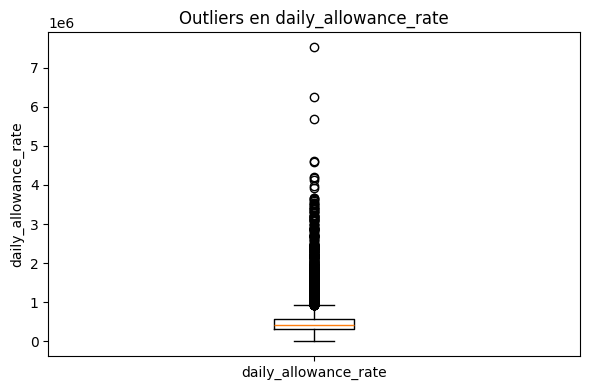

<Figure size 600x400 with 0 Axes>

{'whiskers': [<matplotlib.lines.Line2D at 0x7c3c156b7890>,
 'caps': [<matplotlib.lines.Line2D at 0x7c3c156b44a0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7c3c156b69f0>],
 'medians': [<matplotlib.lines.Line2D at 0x7c3c156b4f20>],
 'fliers': [<matplotlib.lines.Line2D at 0x7c3c156b6540>],
 'means': []}

Text(0.5, 1.0, 'Outliers en allowance_per_km')

([<matplotlib.axis.XTick at 0x7c3c15629a60>], [Text(1, 0, 'allowance_per_km')])

Text(0, 0.5, 'allowance_per_km')

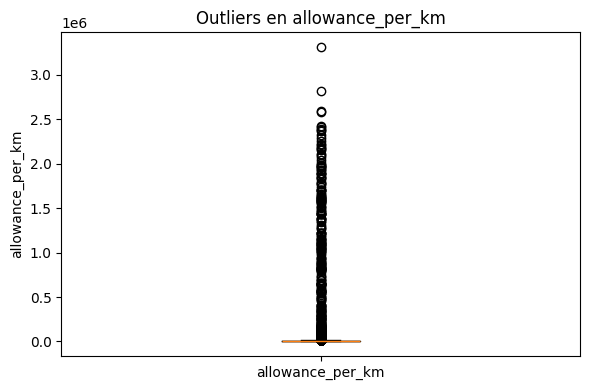

<Figure size 600x400 with 0 Axes>

{'whiskers': [<matplotlib.lines.Line2D at 0x7c3c178c3410>,
 'caps': [<matplotlib.lines.Line2D at 0x7c3c178c3e00>,
 'boxes': [<matplotlib.lines.Line2D at 0x7c3c178c32c0>],
 'medians': [<matplotlib.lines.Line2D at 0x7c3c178cc6b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7c3c178cf950>],
 'means': []}

Text(0.5, 1.0, 'Outliers en purpose_expense_profile')

([<matplotlib.axis.XTick at 0x7c3c178c8980>],
 [Text(1, 0, 'purpose_expense_profile')])

Text(0, 0.5, 'purpose_expense_profile')

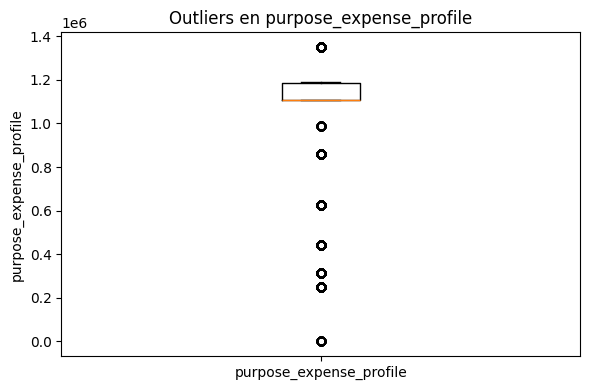

<Figure size 600x400 with 0 Axes>

{'whiskers': [<matplotlib.lines.Line2D at 0x7c3c156b72c0>,
 'caps': [<matplotlib.lines.Line2D at 0x7c3c156b4aa0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7c3c156b75f0>],
 'medians': [<matplotlib.lines.Line2D at 0x7c3c156b7620>],
 'fliers': [<matplotlib.lines.Line2D at 0x7c3c156b5160>],
 'means': []}

Text(0.5, 1.0, 'Outliers en multi_dest_cost_ratio')

([<matplotlib.axis.XTick at 0x7c3c1579f440>],
 [Text(1, 0, 'multi_dest_cost_ratio')])

Text(0, 0.5, 'multi_dest_cost_ratio')

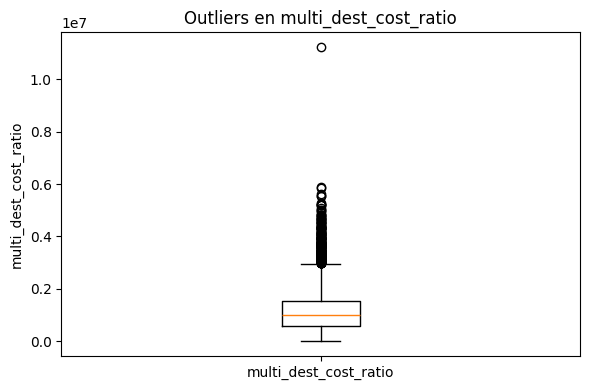

<Figure size 600x400 with 0 Axes>

{'whiskers': [<matplotlib.lines.Line2D at 0x7c3c1786a7b0>,
 'caps': [<matplotlib.lines.Line2D at 0x7c3c178688f0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7c3c1786ae70>],
 'medians': [<matplotlib.lines.Line2D at 0x7c3c17868980>],
 'fliers': [<matplotlib.lines.Line2D at 0x7c3c17841550>],
 'means': []}

Text(0.5, 1.0, 'Outliers en log_total_allowance')

([<matplotlib.axis.XTick at 0x7c3c17864e00>],
 [Text(1, 0, 'log_total_allowance')])

Text(0, 0.5, 'log_total_allowance')

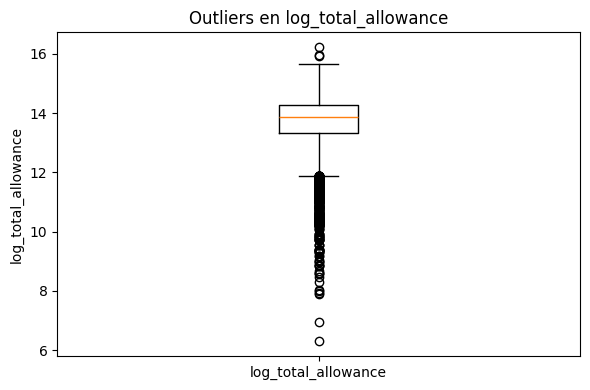

In [ ]:
## Boxplots de variables continuas (solo variables con sentido continuo)
for col in numericas_reales:
    plt.figure(figsize=(6, 4))
    plt.boxplot(X_train[col].dropna())
    plt.title(f"Outliers en {col}")
    plt.xticks([1], [col])
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [ ]:
tc = X_train["total_travel_allowance"].dropna()

# log1p = log(1 + x): comprime la cola y maneja ceros sin problema (determinista)
tc_log = np.log1p(tc)

# Yeo-Johnson aprende un lambda; lo ajustamos SOLO con train
pt = PowerTransformer(method="yeo-johnson")
tc_yj = pt.fit_transform(tc.values.reshape(-1, 1)).ravel()

print(f"Sesgo (skew) original   : {skew(tc):.2f}")
print(f"Sesgo tras log          : {skew(tc_log):.2f}")
print(f"Sesgo tras Yeo-Johnson  : {skew(tc_yj):.2f}   (lambda aprendido = {pt.lambdas_[0]:.2f})")
print("(skew cercano a 0 = mas simetrico)")

Sesgo (skew) original   : 1.33
Sesgo tras log          : -1.46
Sesgo tras Yeo-Johnson  : -0.03   (lambda aprendido = 0.49)
(skew cercano a 0 = mas simetrico)


(array([2.058e+03, 2.227e+03, 3.114e+03, 3.144e+03, 2.531e+03, 2.454e+03,
        1.780e+03, 9.090e+02, 5.260e+02, 3.250e+02, 2.060e+02, 1.130e+02,
        6.500e+01, 5.500e+01, 2.900e+01, 2.500e+01, 2.500e+01, 1.400e+01,
        1.000e+01, 6.000e+00, 6.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([5.39000000e+02, 2.81018975e+05, 5.61498950e+05, 8.41978925e+05,
        1.12245890e+06, 1.40293888e+06, 1.68341885e+06, 1.96389882e+06,
        2.24437880e+06, 2.52485877e+06, 2.80533875e+06, 3.08581872e+06,
        3.36629870e+06, 3.64677867e+06, 3.92725865e+06, 4.20773862e+06,
        4.48821860e+06, 4.76869857e+06, 5.04917855e+06, 5.32965852e+06,
        5.61013850e+06, 5.89061847e+06, 6.17109845e+06, 6.45157842e+06,
        6.73205840e+06, 7.01253837e+06, 7.29301835e+06, 7.57349832e+06

Text(0.5, 1.0, 'Original (skew 1.33)')

(array([1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        3.000e+00, 1.000e+00, 2.000e+00, 4.000e+00, 7.000e+00, 3.000e+00,
        1.000e+01, 1.000e+01, 9.000e+00, 1.700e+01, 4.500e+01, 2.700e+01,
        3.400e+01, 2.570e+02, 3.440e+02, 1.800e+02, 2.310e+02, 3.530e+02,
        4.570e+02, 4.590e+02, 6.620e+02, 1.257e+03, 1.922e+03, 2.075e+03,
        2.882e+03, 3.055e+03, 3.025e+03, 1.411e+03, 6.040e+02, 1.840e+02,
        7.800e+01, 1.300e+01, 2.000e+00, 1.000e+00]),
 array([ 6.29156914,  6.54010954,  6.78864994,  7.03719034,  7.28573075,
         7.53427115,  7.78281155,  8.03135195,  8.27989235,  8.52843275,
         8.77697315,  9.02551356,  9.27405396,  9.52259436,  9.77113476,
        10.01967516, 10.26821556, 10.51675596, 10.76529636, 11.01383677,
        11.26237717, 11.51091757, 11.75945797, 12.00799837, 12.25653877,
        12.50507917, 12.75361958, 13.00215998, 13.25070038, 13.49924078,
        13.74778118, 13.99632158, 14.24486198, 14.49340239, 14.7

Text(0.5, 1.0, 'log (skew -1.46)')

(array([2.200e+01, 6.400e+01, 1.610e+02, 6.570e+02, 3.530e+02, 6.030e+02,
        5.610e+02, 6.870e+02, 1.137e+03, 1.627e+03, 1.418e+03, 1.697e+03,
        1.919e+03, 1.687e+03, 1.798e+03, 1.701e+03, 1.309e+03, 7.820e+02,
        5.090e+02, 3.450e+02, 1.970e+02, 1.480e+02, 7.200e+01, 6.100e+01,
        3.600e+01, 2.900e+01, 2.000e+01, 1.000e+01, 8.000e+00, 4.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([-2.82071974, -2.58987032, -2.3590209 , -2.12817148, -1.89732206,
        -1.66647264, -1.43562322, -1.2047738 , -0.97392439, -0.74307497,
        -0.51222555, -0.28137613, -0.05052671,  0.18032271,  0.41117213,
         0.64202155,  0.87287096,  1.10372038,  1.3345698 ,  1.56541922,
         1.79626864,  2.02711806,  2.25796748,  2.4888169 ,  2.71966631,
         2.95051573,  3.18136515,  3.41221457,  3.64306399,  3.87391341,
         4.10476283,  4.33561225,  4.56646166,  4.79731108,  5.0

Text(0.5, 1.0, 'Yeo-Johnson (skew -0.03)')

Text(0.5, 0.98, 'TotalCharges: efecto de cada transformada sobre el sesgo')

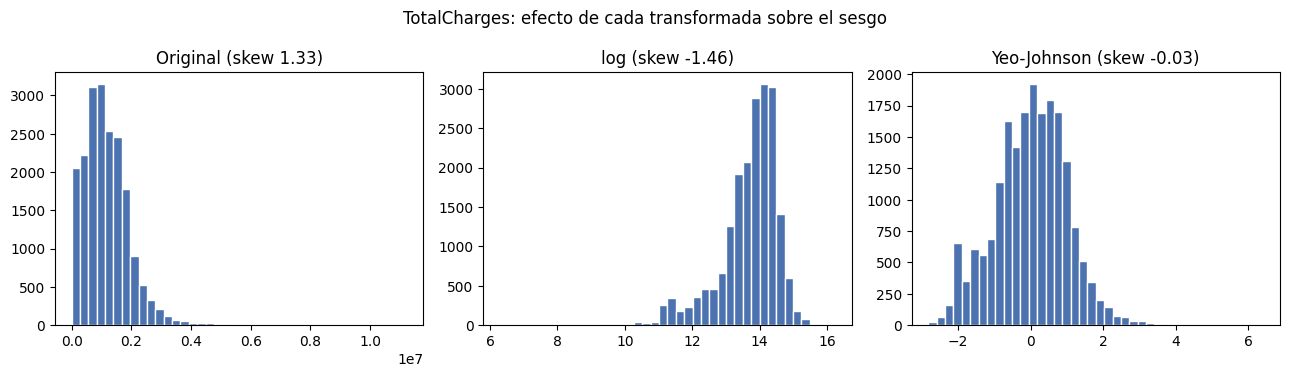

In [ ]:
# Comparar la forma antes y despues de cada transformada
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, datos, titulo in zip(
    axes,
    [tc, tc_log, tc_yj],
    [f"Original (skew {skew(tc):.2f})", f"log (skew {skew(tc_log):.2f})", f"Yeo-Johnson (skew {skew(tc_yj):.2f})"],
):
    ax.hist(datos, bins=40, color="#4C72B0", edgecolor="white")
    ax.set_title(titulo)
fig.suptitle("TotalCharges: efecto de cada transformada sobre el sesgo")
fig.tight_layout()
plt.show()